# 1. A *Plato* catalogue of AGNs

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.time import Time
from astropy import units as u
from astropy import constants as c
from astropy.coordinates import SkyCoord
from ipywidgets import *
from tqdm import tqdm
from pathlib import Path
from mpl_toolkits.axes_grid1 import make_axes_locatable

# PlatoSim libraries
import platosim.smbhb     as bh
import platosim.slurm     as sm
import platosim.utilities as ut
import platosim.plot      as pt
import platosim.noise     as ns
import platosim.starquery as sq
from platosim.lightcurve   import LightCurve
from platosim.slurm        import workerOverview
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:80% !important; }</style>"))

Workaround solutions for the Gaia Archive issues following the infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [3]:
# Paths to where data is stored
path = Path(os.getenv('PLATO_WORKDIR')) / 'smbhb'
idir = path / 'input'
ddir = path / 'data'
sdir = path / 'simulations'
fdir = path / 'figures'

---
## 1. Quasar PLATO-Gaia DR3 catalogue
---

The catalogues presented in this section were generated using `picsim`:

```
python picsim.py --vizier LOPS1 --gaia_quasar --mag_max 19 --project smbhb
python picsim.py --vizier LOPN1 --gaia_quasar --mag_max 19 --project smbhb
```

In [4]:
# Load catalogues and merge to one
ds = pd.read_feather(idir / 'starcat_GaiaDR3_LOPS2.ftr')
dn = pd.read_feather(idir / 'starcat_GaiaDR3_LOPN1.ftr')
df = pd.concat([ds, dn])

#-------------- delete upon new download of LOPS2
Pmag = df.Pmag
ncam = df.ncams  # Insert later
df = df.drop(columns=['source_gaia', 'ncams', 'Pmag'])
df.insert(0, 'ncam', ncam)
df.insert(5, 'Pmag', Pmag)
#------------------

# Number of objects
df.shape[0], df.columns

(20058,
 Index(['ncam', 'source_gaia_dr3', 'ra', 'dec', 'l', 'Pmag', 'b', 'Gmag',
        'BP_RP', 'Ag', 'plx', 'plx_err', 'pm', 'pmra', 'pmra_error', 'pmdec',
        'pmdec_error', 'ruwe', 'class_name', 'p_quasar', 'agn_score', 'qso_var',
        'qso_non', 'host_galaxy', 'z', 'z_err'],
       dtype='object'))

### 1.0. General cuts

In [5]:
# Start make some general cuts
dt0 = df[(df.class_name == 'AGN') & 
         (df. p_quasar > 0.999) & 
         (df.z > 0.09) & 
         (df.z_err < 0.05)]

# Sort after P magnitude
dt0 = dt0.sort_values(by=['ncam', 'Pmag'])

# Convert to percentage
dt0.p_quasar *= 100

# Number of objects
dt0.shape[0]

12985

### 1.1. Proper motion cut (Storey-Fisher+2024)

In [6]:
# Define decontamination line
G_line = np.linspace(5, 19, 100)
mu_line = 10**(0.4*(G_line - 18.25))

# Mark outliers
mu = 10**(0.4*(dt0.Gmag - 18.25))
do1 = dt0[(dt0.pm > mu)]
dt1 = dt0[(dt0.pm < mu)]

# Number of objects
dt1.shape[0]

12973

<IPython.core.display.Javascript object>


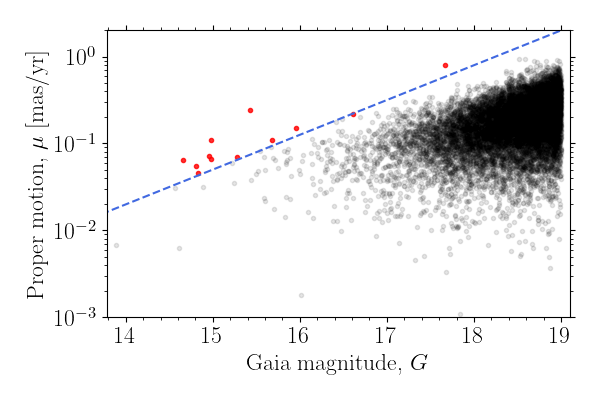

In [7]:
# Plot decontamination
fig = plt.figure(figsize=(6,4))
plt.plot(dt1.Gmag, dt1.pm, '.', c='k', alpha=0.1)
plt.plot(do1.Gmag, do1.pm, '.', c='r', alpha=0.8)
plt.plot(G_line, mu_line, '--', c='royalblue')
plt.xlabel(r'Gaia magnitude, $G$')
plt.ylabel(r'Proper motion, $\mu$ [mas/yr]')
plt.yscale('log')
plt.xlim(min(dt1.Gmag)-0.1, max(dt1.Gmag)+0.1)
plt.ylim(1e-3, 2e0)
plt.tight_layout();

### 1.2. Astrometric fidelity cut (Rubizki+2022)

In [8]:
# # Download (from a terminal) the fidelity_v2 to remove stars with spurious parallaxes:
# # curl -O http://vo.ari.uni-heidelberg.de/gedr3spur/dump.txt.gz
# # This catalogue has a fidelity for 1,467,744,800 stars.

# # Load fidelity_v2 to remove stars with spurious parallaxes
# dx = pd.read_csv(f"{idir}/dump.txt", sep='\t', chunksize=1000000, 
#                  names=["gaiaDR3", "fidelity", "a", "b", "c", "d", "e", "f", "g", "h", "i"]) 

# # Match in chunks since this file is huge!
# dx1 = pd.DataFrame()
# i = 0 
# for dx_i in tqdm(dx, bar_format=ut.tqdmBar()): 
    
#     # Attempt to find star matching our catalogue
# #     dx0 = dx_i.loc[dx_i['gaiaDR3'].isin(df.gaiaDR3)]
# #     print(dx_i.iloc[:,:2])
    
#     # Attempt to find stars we want to discard
#     dx0 = dx_i[dx_i.fidelity < 0.75]
#     dx0 = dx0.iloc[:,:2]
#     dx1 = pd.concat([dx1, dx0])
    
# #     i += 1
# #     if i == 100:
# #         break

# df0 = df.loc[:10]
# dx2.gaiaDR3.loc[0] = df0.gaiaDR3.loc[0]
# dx2.loc[dx2.gaiaDR3.isin(df0.gaiaDR3)]

# dx2.loc[dx2.gaiaDR3.isin(df.gaiaDR3)]
# 
# dex = df.gaiaDR3.isin(dx1.gaiaDR3)
# dx1
dt2 = dt1

### 1.3. QSO probability cut (Butler&Bloom,2011)

In [9]:
# Remove sources below black line above
do3 = dt2
def y(x): return x 
dt3 = dt2[(10**dt2.qso_non > 2.5) & (dt2.qso_non > y(dt2.qso_var))]

# Number of objects
dt3.shape[0]

12395

<IPython.core.display.Javascript object>


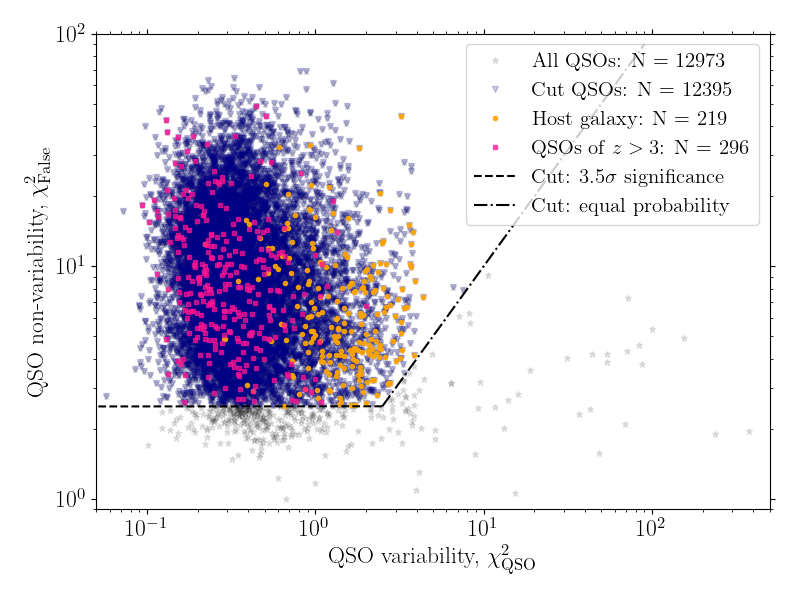

In [10]:
# Check how many of the AGNs that has a confirmed host galaxy
dh3 = dt3[(dt3.host_galaxy == True)]

# All quasar above z > 3
dz3 = dt3[dt3.z > 3]

# Plot diagnostic diagram of Butler and Bloom (2011)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(10**do3.qso_var, 10**do3.qso_non, '*', c='k',        alpha=0.1, ms=5, label=f'All QSOs: N = {do3.shape[0]}')
ax.plot(10**dt3.qso_var, 10**dt3.qso_non, 'v', c='darkblue', alpha=0.2, ms=5, label=f'Cut QSOs: N = {dt3.shape[0]}')
ax.plot(10**dh3.qso_var, 10**dh3.qso_non, '.', c='orange',   alpha=0.9,       label=f'Host galaxy: N = {dh3.shape[0]}')
ax.plot(10**dz3.qso_var, 10**dz3.qso_non, 's', c='deeppink', alpha=0.7, ms=3, label=r'QSOs of $z>3$: ' + f'N = {dz3.shape[0]}')
ax.plot([0, 2.5], [1, 2.5],         '--', c='k', label=r'Cut: 3.5$\sigma$ significance')
ax.plot([2.5, 90], [y(2.5), y(90)], '-.', c='k', label='Cut: equal probability')
ax.set_xlabel(r'QSO variability, $\chi_{\rm QSO}^2$')
ax.set_ylabel(r'QSO non-variability, $\chi_{\rm False}^2$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(5e-2, 5e2)
ax.set_ylim(0.9, 100)
ax.legend()
plt.tight_layout();
# fig.savefig(f'{fdir}/variability_QSO.png', bbox_inches='tight', dpi=300)

### 1.4. Cross-match with Quaia catalogue (Storey-Fisher+2024)

In [11]:
# Load Quaia catalogue
filename = f'{ddir}/quaia_G20.5.fits'
data = Table.read(filename, format='fits')
df_quaia = data.to_pandas()
df_quaia.head()

,source_id,unwise_objid,redshift_quaia,redshift_quaia_err,ra,dec,l,b,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,mag_w1_vg,mag_w2_vg,pm,pmra,pmdec,pmra_error,pmdec_error
0,6459630980096,b'0453p000o0014479',0.416867,0.060812,44.910498,0.189649,176.659434,-48.835164,20.173105,20.200150,18.871586,14.774343,13.923867,0.383797,0.217806,-0.316007,0.679419,0.608799
1,10892037246720,b'0453p000o0015876',1.736468,0.096594,45.188575,0.282424,176.851544,-48.570856,18.787239,19.080688,18.240915,15.219950,13.868094,0.155406,-0.098037,-0.120580,0.257395,0.223107
2,15839839588736,b'0453p000o0017020',1.513049,0.063187,45.189480,0.359195,176.769129,-48.516842,18.888464,19.171280,18.509371,15.317786,14.013617,0.448925,-0.316088,0.318781,0.360595,0.326582
3,19275813399552,b'0453p000o0024506',2.422632,0.055260,44.835496,0.237432,176.527928,-48.855622,20.330523,20.320410,19.841410,17.273508,16.396996,1.085342,1.062588,0.221073,0.739487,0.625105
4,22780506725760,b'0453p000o0016209',2.852854,0.076640,44.799365,0.303557,176.417664,-48.835309,19.218422,19.486340,18.814501,16.027142,15.041919,0.523211,0.168237,0.495425,0.361439,0.269473


In [12]:
# Match catalogues
dx4 = df_quaia
dt4 = dt3[dt3['source_gaia_dr3'].isin(dx4['source_id'])].sort_values(by=['source_gaia_dr3']).reset_index(drop=True)
dx4 = dx4[dx4['source_id'].isin(dt4['source_gaia_dr3'])].sort_values(by=['source_id']).reset_index(drop=True)

# Replace redshift from Quaia
dt4['z']     = dx4.redshift_quaia
dt4['z_err'] = dx4.redshift_quaia_err

# Sort after P magnitude
dt4 = dt4.sort_values(by=['ncam', 'Gmag'])

### 1.6 Assemble final catalogue

In [13]:
# Store data frames
dt = dt4
# dn = dn4
# ds = ds4

# Sperate LOPS2 and LOPN1
ds = dt[dt.b < 0]
dn = dt[dt.b > 0]

# Seperate camera visibility
dt06 = dt[dt.ncam ==  6]
dt12 = dt[dt.ncam == 12]
dt18 = dt[dt.ncam == 18]
dt24 = dt[dt.ncam == 24]

# Store global dfs
dt = dt.reset_index(drop=True)
ds = dt[dt.b < 0].sort_values(by=['ncam', 'Pmag']).reset_index(drop=True)
dn = dt[dt.b > 0].sort_values(by=['ncam', 'Pmag']).reset_index(drop=True)
dt.head()

,ncam,source_gaia_dr3,ra,dec,l,Pmag,b,Gmag,BP_RP,Ag,...,pmdec_error,ruwe,class_name,p_quasar,agn_score,qso_var,qso_non,host_galaxy,z,z_err
0,6,1331085410995536640,248.004632,37.630550,60.342100,15.656564,42.939346,15.840618,0.579854,1.8440,...,0.036347,1.043414,AGN,100.0,0.403316,-0.316279,0.683840,False,1.476276,0.446821
1,6,4828236384002699520,57.747604,-52.676254,263.037832,15.658949,-48.152123,15.851448,0.611596,1.8750,...,0.039195,1.057984,AGN,100.0,0.588843,-0.438903,0.687227,False,1.542538,0.402480
2,6,1646883258074187520,242.960135,69.737907,103.023904,15.855906,38.716636,16.026461,0.530438,1.6903,...,0.043050,0.924078,AGN,100.0,0.289868,0.099042,0.419567,False,1.021370,0.296468
3,6,1637030740536551296,256.509188,68.960115,99.934050,15.865224,34.569524,16.031271,0.514276,1.3885,...,0.044007,1.073094,AGN,100.0,0.317068,-0.351945,0.463984,False,0.451021,0.164616
4,6,1326101290427211904,246.530178,33.987571,55.200032,15.979334,43.794674,16.138632,0.490378,1.2550,...,0.039655,1.063018,AGN,100.0,0.142509,0.642049,0.867423,True,0.291247,0.121641


<IPython.core.display.Javascript object>


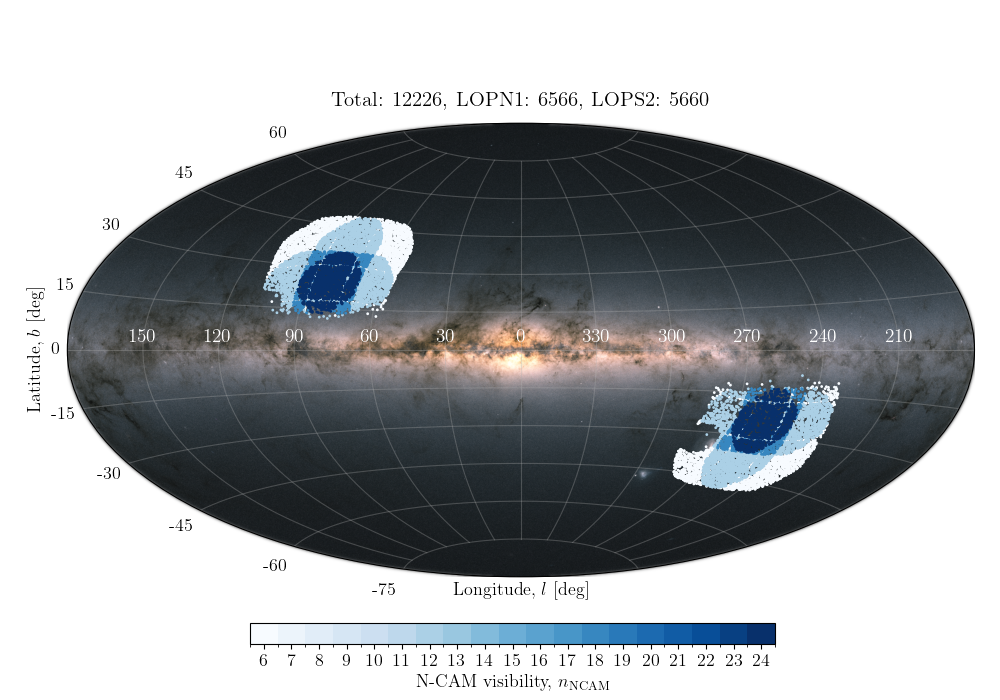

In [14]:
# Show matching sources in sky
fig, ax = bh.plot_aitoff(dt)

<IPython.core.display.Javascript object>


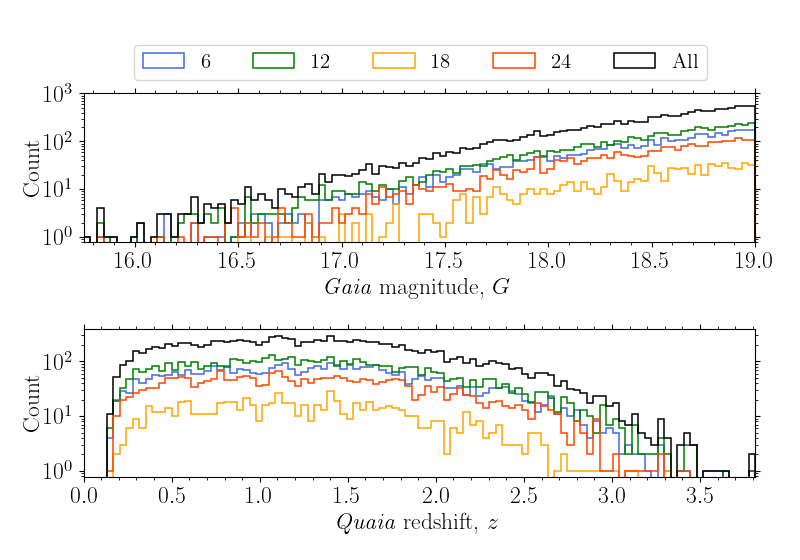

In [15]:
# Plot histograms
lw, N = 1.1, 100
c = ['royalblue', 'green', 'orange', 'orangered', 'k']
# c = ['skyblue', 'deepskyblue', 'dodgerblue', 'royalblue', 'k']
fig = plt.figure(figsize=(8,2.8*2))

ax1 = plt.subplot(2, 1, 1)
G_min, G_max = dt4.Gmag.min(), dt4.Gmag.max()
ax1.hist(dt06.Gmag, bins=N, range=(G_min, G_max), histtype='step', ec=c[0], lw=lw, label='6')
ax1.hist(dt12.Gmag, bins=N, range=(G_min, G_max), histtype='step', ec=c[1], lw=lw, label='12')
ax1.hist(dt18.Gmag, bins=N, range=(G_min, G_max), histtype='step', ec=c[2], lw=lw, label='18')
ax1.hist(dt24.Gmag, bins=N, range=(G_min, G_max), histtype='step', ec=c[3], lw=lw, label='24')
ax1.hist(dt.Gmag,   bins=N, range=(G_min, G_max), histtype='step', ec=c[4], lw=lw, label='All')
ax1.set_xlabel(r'\textit{Gaia} magnitude, $G$')
ax1.set_xlim(G_min, 19)
ax1.set_ylim(0.8, 1000)
ax1.legend(loc='upper left', bbox_to_anchor=(0.06, 1.4), ncols=5)

ax2 = plt.subplot(2, 1, 2)
z_min, z_max = dt4.z.min(), dt4.z.max()
ax2.hist(dt06.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[0], lw=lw)
ax2.hist(dt12.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[1], lw=lw)
ax2.hist(dt18.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[2], lw=lw)
ax2.hist(dt24.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[3], lw=lw)
ax2.hist(dt.z,   bins=N, range=(z_min, z_max), histtype='step', ec=c[4], lw=lw)
ax2.set_xlabel(r'\textit{Quaia} redshift, $z$')
ax2.set_xlim(0, z_max)

for ax in [ax1, ax2]:
    ax.set_ylabel('Count')
    ax.set_yscale('log')
    ax.get_yaxis().set_label_coords(-0.06, 0.5)
plt.tight_layout()
# fig.savefig(f'{fdir}/historgram_quasars.png', bbox_inches='tight', dpi=200)

<IPython.core.display.Javascript object>


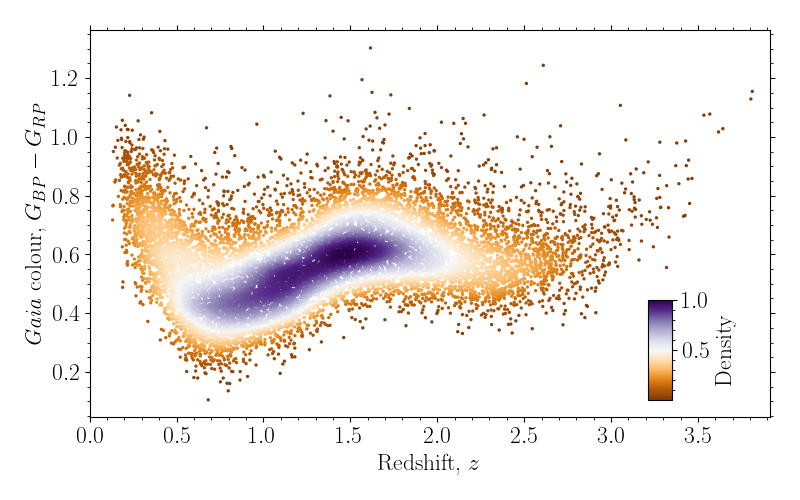

In [45]:
# Plot redshift-colour correlation
x, y, z, dex = ut.sortAfterDensity(dt.z.to_numpy(), dt.BP_RP.to_numpy())
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
im = ax.scatter(x, y, c=z/np.max(z), s=2, cmap="PuOr")
cbarax = fig.add_axes([0.81, 0.2, 0.03, 0.2])
cbar = plt.colorbar(im, orientation='vertical', cax=cbarax)
cbar.set_label('Density')
ax.set_ylabel(r'\textit{Gaia} colour, $G_{BP} - G_{RP}$')
ax.set_xlabel(r'Redshift, $z$')
ax.set_xlim(0, z_max+0.1)
plt.tight_layout()
# fig.savefig(f'{fdir}/correlation_redshift_vs_colour.png', bbox_inches='tight', dpi=200)

#### *Limiting magnitude*

In [46]:
dx = dt.sort_values(by=['Pmag'], ascending=False)

In [47]:
# Number of sources below 17.5
dx[(dx.b < 0) & (dx.Pmag < 17.5)].shape[0], dx[(dx.b > 0) & (dx.Pmag < 17.5)].shape[0]

(494, 600)

In [48]:
# Number of targets below 17.0 mag
dx[(dx.b < 0) & (dx.Pmag < 17)].shape[0], dx[(dx.b > 0) & (dx.Pmag < 17)].shape[0]

(170, 177)

In [49]:
# Select limited magnitude
dx = dx[dx.Pmag < 17.5]

<IPython.core.display.Javascript object>


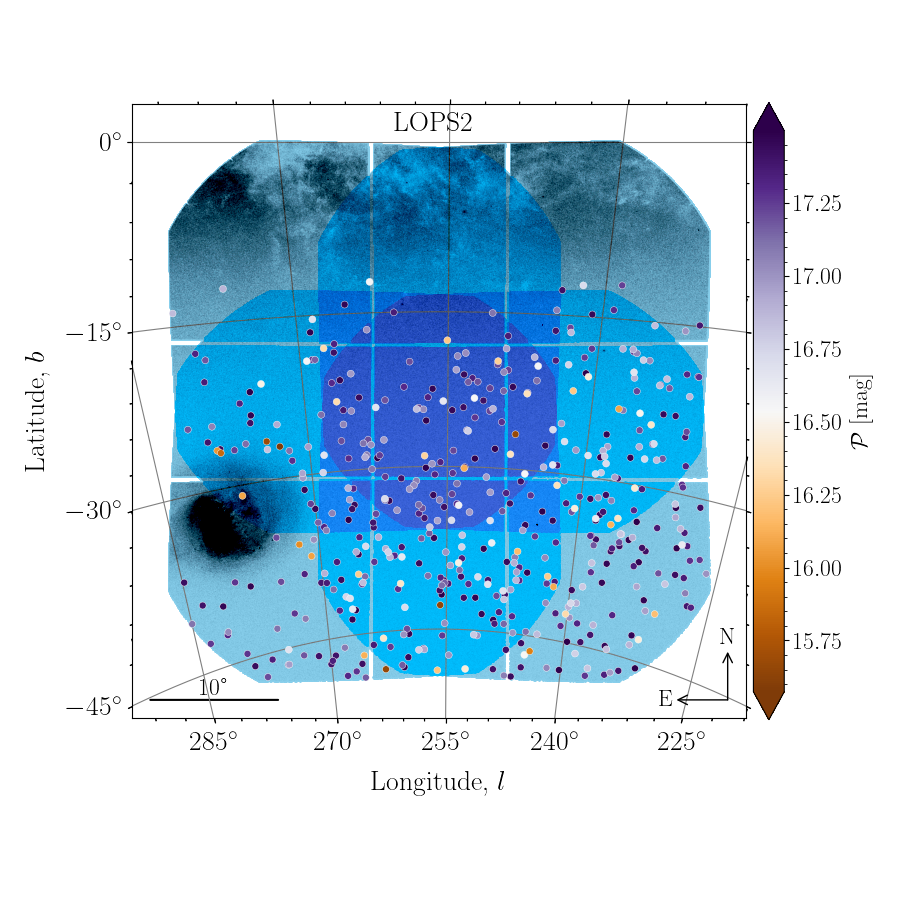

In [50]:
fig, ax = pt.plotPlatoFOV('LOPS2', system='galactic', fovSize=30, 
                          ncamStars=True, ncamMap='PLATO-CS', showGalactic=True,
                          raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=100, lw=0.3, ec='w',
                          clabel=r'$\mathcal{P}$ [mag]', cmap='PuOr', figsize=(9,9))
ax.text(340, 670, 'LOPS2', horizontalalignment='center', verticalalignment='center', fontsize=20)
# fig.savefig(fdir / 'skymap_quasars_LOPS2_mag175.png', bbox_inches='tight', dpi=200)

<IPython.core.display.Javascript object>


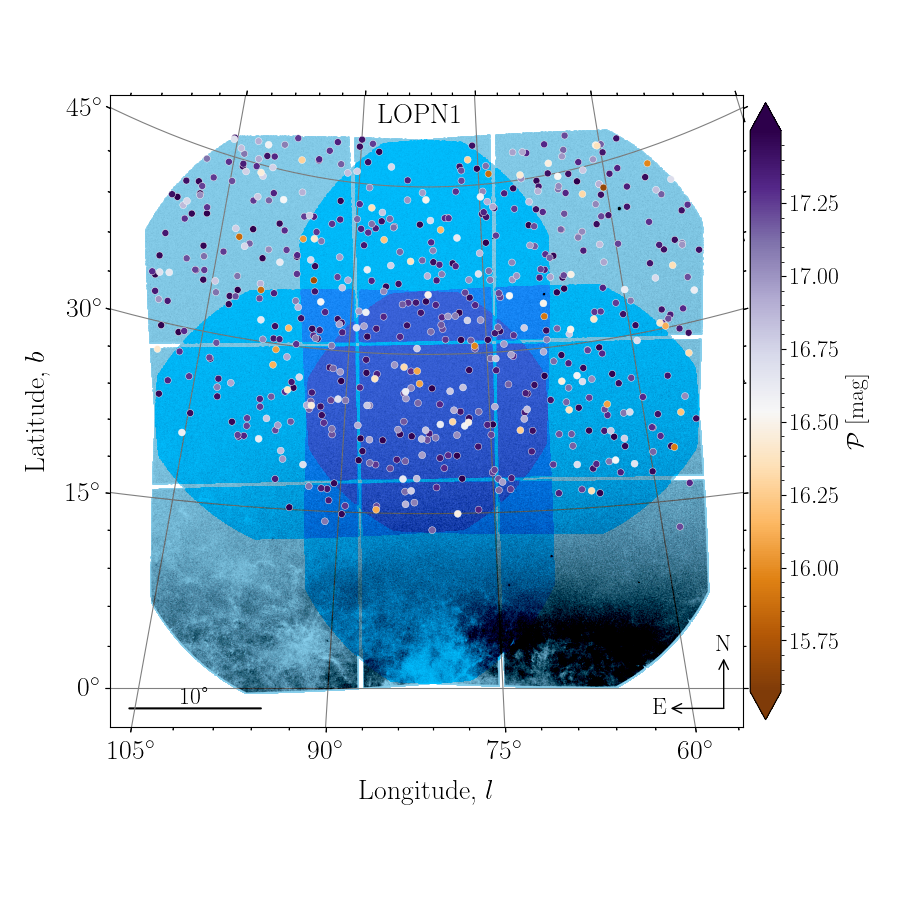

In [51]:
fig, ax = pt.plotPlatoFOV('LOPN1', system='galactic', fovSize=30, 
                          ncamStars=True, ncamMap='PLATO-CS', showGalactic=True,
                          raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=100, lw=0.3, ec='w',
                          clabel=r'$\mathcal{P}$ [mag]', cmap='PuOr', figsize=(9,9))
ax.text(340, 670, 'LOPN1', horizontalalignment='center', verticalalignment='center', fontsize=20)
# fig.savefig(fdir / f'skymap_quasars_LOPN1_mag175.png', bbox_inches='tight', dpi=200)

### 1.6 Save PLATO catalogue for NSR simulations

In [52]:
# # Search for stars wihtin 60 arcsec (3 pixels)
# radius = 60

In [16]:
# # Fetch contaminants of LOPS2 targets
# n = ds.shape[0]
# for i in tqdm(range(n), bar_format=ut.tqdmBar()):
#     # Query cone around each target
#     di = ds.loc[i]
#     dc = sq.gaiaQueryCone(di.ra, di.dec, radius=radius/3600, flag_stellar=True)
#     # Rename after target and keep contaminants
#     dc.source_gaia_dr3 = [di.source_gaia_dr3] * dc.shape[0]
#     if (dc.source_gaia_dr3 == di.source_gaia_dr3).any():
#         dc = dc[dc.dis != 0]
#     # Add catalogues together
#     if i == 0:
#         ds_con = dc
#     else:
#         ds_con = pd.concat([ds_con, dc])

In [17]:
# # Save contaminant catalogue for LOPS2
# ds_con = ds_con.reset_index(drop=True)
# ds_con.insert(6, 'Pmag', ut.passbandConversionG2P(ds_con.Gmag, ds_con.BP_RP))
# ds_con.to_feather(f'{idir}/starcat_PlatoCS_QSO_LOPS2_contaminants.ftr')

In [ ]:
# # Fetch contaminants of LOPN1 targets
# n = dn.shape[0]
# for i in tqdm(range(n), bar_format=ut.tqdmBar()):
#     # Query cone around each target
#     di = dn.loc[i]
#     dc = sq.gaiaQueryCone(di.ra, di.dec, radius=radius/3600, flag_stellar=True)
#     # Rename after target and keep contaminants
#     dc.source_gaia_dr3 = [di.source_gaia_dr3] * dc.shape[0]
#     if (dc.source_gaia_dr3 == di.source_gaia_dr3).any():
#         dc = dc[dc.dis != 0]
#     # Add catalogues together
#     if i == 0:
#         dn_con = dc
#     else:
#         dn_con = pd.concat([dn_con, dc])

In [ ]:
# # Save contaminant catalogue for LOPN1
# dn_con = dn_con.reset_index(drop=True)
# dn_con.insert(6, 'Pmag', ut.passbandConversionG2P(dn_con.Gmag, dn_con.BP_RP))
# dn_con.to_feather(f'{idir}/starcat_PlatoCS_QSO_LOPN1_contaminants.ftr')

In [ ]:
# # Generate SLURM paramterisations files
# sm.getParamFile(np.arange(1, ds.shape[0]), np.arange(1,5), cameras=None, quarters=None, fcam=False, ofile=f'{idir}/cluster_ncam_LOPS2.data');
# sm.getParamFile(np.arange(1, dn.shape[0]), np.arange(1,5), cameras=None, quarters=None, fcam=False, ofile=f'{idir}/cluster_ncam_LOPN1.data');

### 1.7. Add noise parameters to catalogue (NSR vs. G-mag)

We here present the noise budget of simulated light curves using the two generated catalogues from the previous section.

In [ ]:
# Define output file names
ofile_camera_LOPN1 = f'{sdir}/nsr/nsr_per_camera_LOPN1.ftr'
ofile_camera_LOPS2 = f'{sdir}/nsr/nsr_per_camera_LOPS2.ftr'
ofile_star_LOPN1 = f'{sdir}/nsr/nsr_per_star_LOPN1.ftr'
ofile_star_LOPS2 = f'{sdir}/nsr/nsr_per_star_LOPS2.ftr'

In [ ]:
# Fetch the NSR per camera and star
# lcs = LightCurve(f'{sdir}/nsr/LOPN1', 'multi')
# lcs.get_nsr_per_camera(ofile_camera_LOPN1, suffix='hdf5', quarter=1)
# lcs = LightCurve(f'{sdir}/nsr/LOPS2', 'multi')
# lcs.get_nsr_per_camera(ofile_camera_LOPS1, suffix='hdf5', quarter=1)
# lcs = LightCurve(f'{sdir}/nsr/LOPN1', 'multi')
# lcs.get_nsr_per_star(ofile_star_LOPN1, suffix='hdf5', quarter=1)
# lcs = LightCurve(f'{sdir}/nsr/LOPS2', 'multi')
# lcs.get_nsr_per_star(ofile_star_LOPS2, suffix='hdf5', quarter=1)

In [ ]:
# Load results
dn_camera = pd.read_feather(ofile_camera_LOPN1)
ds_camera = pd.read_feather(ofile_camera_LOPS2)
dn_star = pd.read_feather(ofile_star_LOPN1)
ds_star = pd.read_feather(ofile_star_LOPS2)

In [ ]:
# Add noise columns to LOPN1
dn['ncon'] = dn_star.ncon
dn['SPR']  = dn_star.SPR
dn['rOA']  = dn_star.rOA
dn['NSR']  = dn_star.NSR

# Add noise columns to LOPS2
ds['ncon'] = ds_star.ncon
ds['SPR']  = ds_star.SPR
ds['rOA']  = ds_star.rOA
ds['NSR']  = ds_star.NSR

# Combine catalogues and sort after N-CAM
dt = pd.concat([ds, dn]).sort_values(by=['ncam', 'Gmag']).reset_index(drop=True)
dt.head()

In [ ]:
# Save catalogue to avoid running section 1 again
ds.to_feather(idir / 'starcat_PlatoCS_QSO_LOPS2_targets.ftr')
dn.to_feather(idir / 'starcat_PlatoCS_QSO_LOPN1_targets.ftr')

#### *Plots for paper*

In [ ]:
# Investigate parameters
fig, ax = plt.subplots(1, 3, figsize=(10, 3))

ax[0].hist(dt.SPR, bins=80)
ax[0].set_xlabel('SPR')
ax[0].set_ylabel('Counts')
ax[0].set_yscale('log')
ax[0].set_xlim(0, 1)

ax[1].hist(dt.ncon, bins=300)
ax[1].set_xlabel(r'$n_{\rm contaminants}$')
ax[1].set_yscale('log')
ax[1].set_xlim(0, 60)

ax[2].hist(dt.rOA, bins=80)
ax[2].set_xlabel(r'$\vartheta_{\rm OA}$ [deg]')
ax[2].set_xlim(7, 20)

plt.tight_layout();

In [ ]:
# Plot camera level NSR for LOPN1
col = 'rOA'
lim = 0.01
dx = dn_camera.sort_values(by=[col], ascending=False)
da = dx[dx.SPR > lim]
db = dx[dx.SPR < lim]
fig, ax = pt.plotNSRvsMagnitude(db, column=col, passband='P', 
                                show_ncam_noise_limits=1, 
                                legend='SMBHB', figsize=(9, 6))
ax.plot(da.mag, da.NSR, 'k.', alpha=0.1, zorder=-1)
ax.set_title('Noise budget at camera level')
ax.set_ylim(dx.NSR.min(), dx.NSR.max());

In [ ]:
# Plot camera level NSR for LOPS2
col = 'rOA'
lim = 0.01
dx = ds_camera
dx = dx.sort_values(by=[col], ascending=False)
da = dx[dx.SPR > lim]
db = dx[dx.SPR < lim]
fig, ax = pt.plotNSRvsMagnitude(db, column=col, passband='P', 
                                show_ncam_noise_limits=1, 
                                legend='SMBHB', figsize=(9, 6))
ax.plot(da.mag, da.NSR, 'k.', alpha=0.1, zorder=-1)
ax.set_title('Noise budget at camera level')
ax.set_ylim(dx.NSR.min(), dx.NSR.max());

In [ ]:
# Plot mission level NSR for LOPN1
col = 'ncam'
lim = 0.01
dx = dn_star
dx = dx.sort_values(by=[col], ascending=False)
da = dx[dx.SPR > lim]
db = dx[dx.SPR < lim]
fig, ax = pt.plotNSRvsMagnitude(db, column=col, passband='P', 
                                show_ncam_noise_limits=False,
                                figsize=(9, 6))
ax.plot(da.mag, da.NSR, 'k.', alpha=0.1, zorder=-1)
ax.set_title('Noise budget at mission level')
ax.set_ylim(dx.NSR.min(), dx.NSR.max());

In [ ]:
# Plot mission level NSR for LOPS2
col = 'ncam'
lim = 0.01
dx = ds_star
ds = dx.sort_values(by=[col], ascending=False)
db = dx[dx.SPR < lim]
da = dx[dx.SPR > lim]
fig, ax = pt.plotNSRvsMagnitude(db, column=col, passband='P',
                                show_ncam_noise_limits=False, 
                                figsize=(9, 6))
ax.plot(da.mag, da.NSR, 'k.', alpha=0.2, zorder=-1)
ax.set_title('Noise budget at mission level')
ax.set_ylim(dx.NSR.min(), dx.NSR.max());

#### *Combine plots above into a single figure for the paper* 

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(9,6))
lim = 0.01
cmap = 'rainbow'
cmap = plt.cm.get_cmap(cmap)

# Load data and sort
col = 'rOA'
dn = pd.read_feather(f'{sdir}/nsr/nsr_per_camera_LOPN1.ftr')
ds = pd.read_feather(f'{sdir}/nsr/nsr_per_camera_LOPS2.ftr')
df = pd.concat([dn, ds]).sort_values(by=[col], ascending=False)
df.NSR /= 1e3
db = df[df.SPR < lim]
da = df[df.SPR > lim]
# Plot simulations
ax[0].plot(da.mag, da.NSR, 'ko', ms=1, alpha=0.05, zorder=-1)
im = ax[0].scatter(db.mag, db.NSR, s=3, alpha=1, zorder=1, c=db[col], cmap=cmap)
ticks = [0.8, 7, 14, 19.4]
cb = plt.colorbar(im, pad=0.01, ticks=ticks, location='top')
cb.set_label(r'$\vartheta_{\rm OA}$ [$^{\circ}$]')
# Plot noise curves        
mag = np.linspace(0, 20, 100)
noise_jitter = ut.getJitterNoiseLimitNSR(rms=0.04, tdur=3600, camType='normal') / 1e3
noise_photon = ut.getPhotonNoiseLimitNSR(mag, passband='P', ncam=1) / 1e3
noise_background = ut.getBackgroundNoiseLimitNSR(mag, passband='P', ncam=1) / 1e3
noise = np.sqrt(noise_jitter**2 + noise_photon**2 + noise_background**2)
ax[0].plot(mag, noise_photon, '-.', c='deeppink', lw=1.5, zorder=2, label='Photon noise')
ax[0].plot(mag, noise_background, ':', c='deeppink', lw=1.5, zorder=2, label='Sky/read noise')
ax[0].plot(mag, noise, '-', c='orange', lw=2,  zorder=2, label='Noise model')
# Settings
dx = (df.mag.max() - df.mag.min()) * 1e-2
ax[0].set_xlim(df.mag.min()-dx, df.mag.max()+dx)
ax[0].set_ylim(3e-1, 1e3)
ax[0].set_yscale('log')
ax[0].legend(loc='upper left')

# Load data and sort
col = 'ncam'
dn = pd.read_feather(f'{sdir}/nsr/nsr_per_star_LOPN1.ftr')
ds = pd.read_feather(f'{sdir}/nsr/nsr_per_star_LOPS2.ftr')
df = pd.concat([dn, ds]).sort_values(by=[col], ascending=False)
df.NSR /= 1e3
db = df[df.SPR < lim]
da = df[df.SPR > lim]
# Plot simulations
ax[1].plot(da.mag, da.NSR, 'ko', ms=2, alpha=0.05, zorder=-1)
im1 = ax[1].scatter(db.mag, db.NSR, s=3, alpha=1, zorder=1, c=db[col], cmap=cmap)
cbins = np.arange(db[col].min(), db[col].max()+2, 1)
ticks = np.array([1, 6, 12, 18, 24]) + 0.5 
norm  = pt.discretizeColorbar(cbins=cbins, cmap=cmap)
cb = plt.colorbar(im1, pad=0.01, spacing='proportional', location='top',
                  ticks=ticks, boundaries=cbins, format='%1i')
cb.set_label(r'$n_{\rm CAM}$')
cb.minorticks_off()
# Settings
dx = (df.mag.max() - df.mag.min()) * 1e-2
ax[1].set_xlim(df.mag.min()-dx, df.mag.max()+dx)
ax[1].set_ylim(1e-1, 1e2)
ax[1].set_yscale('log')

# Common settings
fig.text(0.5, 0.02, r'PLATO magnitude, $\mathcal{P}$', ha='center')
fig.text(0.04, 0.5, r'NSR [ppt h$^{-1/2}$]', va='center', rotation='vertical')
plt.subplots_adjust(hspace=0.1)
# fig.savefig(f'{fdir}/nsr_quasars.png', bbox_inches='tight', dpi=300)

---
## 2. Catalogue of best PLATO SMBHB candidates
---
These candidates will be simulated for paper I

In [18]:
dn = pd.read_feather(f'{idir}/starcat_PlatoCS_QSO_LOPN1_targets.ftr')
ds = pd.read_feather(f'{idir}/starcat_PlatoCS_QSO_LOPS2_targets.ftr')
dt = pd.concat([dn, ds])
# Placeholder for candidates
dc = pd.DataFrame()

### 2.1 GASP candidates (Huijse+2025)

#### *GASP catalogue*

In [19]:
# Load GASP catalogue
filename = f'{ddir}/gasp.csv'
df_gasp = pd.read_csv(filename)

# Add Galactic coordinates
gal = SkyCoord(df_gasp.ra, df_gasp.dec, frame='icrs', unit=u.deg).galactic
df_gasp['l'] = gal.l.deg
df_gasp['b'] = gal.b.deg
df_gasp.head()

,gaia_dr3_id,log_bf_PR,log_bf_PR_std,period,period_std,ra,dec,bp_rp,mean_mag_g_fov,quaia_unwise_id,...,CatNorth_PS1_id,AllWISE,AllWISE_R90_id,AllWISE_C75_id,Milliquas_v65_id,SDSS_DR14Q_id,LQAC_v5,Gaia_unWISE_id,l,b
0,2355222626225792,-1.508667,-2.855496,515.780467,25.322481,47.452499,3.154205,0.515883,19.678646,0468p030o0013998,...,1.117805e+17,J030948.60+030915.0,J030948.60+030915.0,J030948.60+030915.0,WISEA J030948.60+030915.0,NaN,NaN,0468p030o0013998,176.152214,-44.946271
1,2525131532946560,2.379494,0.771844,440.845796,20.916907,48.556532,3.952636,0.699678,19.647911,0486p045o0002890,...,1.127405e+17,J031413.56+035709.4,J031413.56+035709.4,J031413.56+035709.4,SDSS J031413.56+035709.4,NaN,NaN,0486p045o0002890,176.429483,-43.600065
2,7627415241299200,0.740170,-1.285753,169.373403,1.834795,45.664462,6.947335,0.743160,19.997242,0457p075o0002490,...,1.163305e+17,J030239.47+065650.4,J030239.47+065650.4,J030239.47+065650.4,SDSS J030239.47+065650.4,NaN,NaN,0457p075o0002490,170.705676,-43.425082
3,8314648663843456,2.501854,0.987029,539.604663,10.384097,43.877653,7.432423,0.647360,16.272747,0442p075o0010435,...,1.169104e+17,J025530.63+072556.7,J025530.63+072556.7,J025530.63+072556.7,RX J02555+0725,NaN,LQAC_043+007_001,0442p075o0010435,168.404355,-44.213207
4,8531419957948672,-0.034764,-2.145793,503.263610,32.593152,44.764676,7.854109,0.969009,19.564423,0442p075o0017138,...,1.174204e+17,J025903.52+075114.7,J025903.52+075114.7,J025903.52+075114.7,WISEA J025903.52+075114.7,NaN,NaN,0442p075o0017138,168.960902,-43.324841


<IPython.core.display.Javascript object>


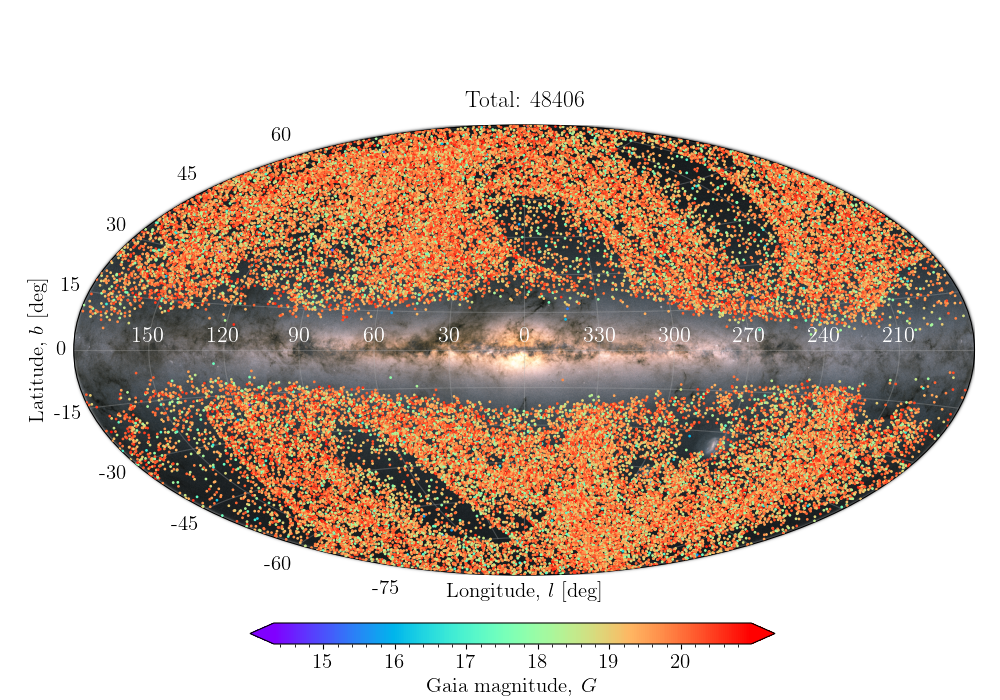

In [20]:
# Plot all candidates
fig, ax = pt.drawStarsInSkyAitoff(
    df_gasp.ra, df_gasp.dec, column=df_gasp.mean_mag_g_fov, 
    cbarLabel=r'Gaia magnitude, $G$', title=f'Total: {df_gasp.shape[0]}',
    color='orange', fs=15, figsize=(10,7));

In [21]:
# Match to original catalogues to find targets within LOPs
dx_gasp = dt[dt['source_gaia_dr3'].isin(df_gasp['gaia_dr3_id'])].sort_values(by=['source_gaia_dr3'])
dt_gasp = df_gasp[df_gasp['gaia_dr3_id'].isin(dt['source_gaia_dr3'])].sort_values(by=['gaia_dr3_id'])

# Sperate LOPS2 and LOPN1
ds_gasp = dt_gasp[dt_gasp.b < 0]
dn_gasp = dt_gasp[dt_gasp.b > 0]

<IPython.core.display.Javascript object>


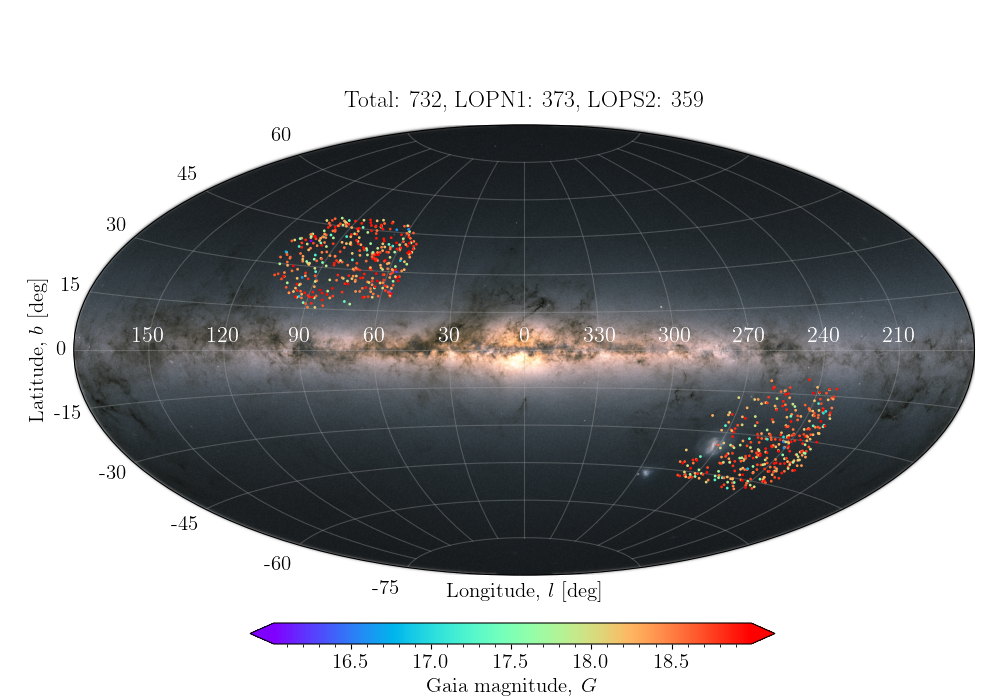

In [22]:
# Plot candidates within LOPs
fig, ax = pt.drawStarsInSkyAitoff(
    dt_gasp.ra, dt_gasp.dec, 
    column=dt_gasp.mean_mag_g_fov, 
    cbarLabel=r'Gaia magnitude, $G$',
    title=(f'Total: {dt_gasp.shape[0]}, ' + 
           f'LOPN1: {dn_gasp.shape[0]}, ' + 
           f'LOPS2: {ds_gasp.shape[0]}'),
   fs=15, figsize=(10,7));

#### *GASP candidates*

In [23]:
# Load GASP SMBHB candidates
filename = f'{ddir}/gasp_only_candidates.csv'
df_gasp_cand = pd.read_csv(filename)

# Add Galactic coordinates
gal_gasp_cand = SkyCoord(df_gasp_cand.ra, df_gasp_cand.dec, frame='icrs', unit=u.deg).galactic
df_gasp_cand['l'] = gal_gasp_cand.l.deg
df_gasp_cand['b'] = gal_gasp_cand.b.deg
df_gasp_cand.head()

,gaia_dr3_id,log_bf_PR,log_bf_PR_std,period,period_std,ra,dec,bp_rp,mean_mag_g_fov,quaia_unwise_id,...,CatNorth_PS1_id,AllWISE,AllWISE_R90_id,AllWISE_C75_id,Milliquas_v65_id,SDSS_DR14Q_id,LQAC_v5,Gaia_unWISE_id,l,b
0,44567982277833984,3.285549,1.289423,502.888692,11.384989,55.700875,17.633334,0.830851,20.216707,0555p181o0004099,...,1.291606e+17,NaN,J034248.22+173759.7,J034248.22+173759.7,SDSS J034248.21+173800.0,NaN,NaN,0555p181o0004099,170.700701,-28.932814
1,2407922424651417344,3.435278,1.831403,539.185382,10.093248,354.252482,-14.557573,0.688057,19.432816,3537m152o0018381,...,9.053354e+16,J233700.59-143327.2,J233700.59-143327.2,J233700.59-143327.2,WISEA J233700.59-143327.2,NaN,NaN,3537m152o0018381,65.144280,-68.591489
2,1270114875599306112,4.574719,2.902317,574.839149,7.595437,230.379888,25.434566,0.600286,19.537634,2300p257o0008446,...,1.385223e+17,J152131.17+252604.5,J152131.17+252604.5,J152131.17+252604.5,SDSS J152131.17+252604.4,152131.17+252604.4,LQAC_230+025_033,2300p257o0008446,38.707134,56.439365
3,2482974779125235584,3.088276,1.708694,513.618539,9.833293,17.327541,-4.802565,0.528299,19.851114,0167m046o0007271,...,1.022302e+17,J010918.61-044809.0,J010918.61-044809.0,J010918.61-044809.0,WISEA J010918.61-044809.0,NaN,NaN,0167m046o0007271,134.522780,-67.271238
4,2509986073263441280,3.933530,2.175033,554.846306,14.200083,22.909119,-0.170838,0.570103,19.601595,0226p000o0008864,...,1.077902e+17,NaN,NaN,J013138.18-001014.5,SDSS J013138.18-001015.0,013138.18-001015.0,LQAC_022-000_048,0226p000o0008864,144.285728,-61.364788


<IPython.core.display.Javascript object>


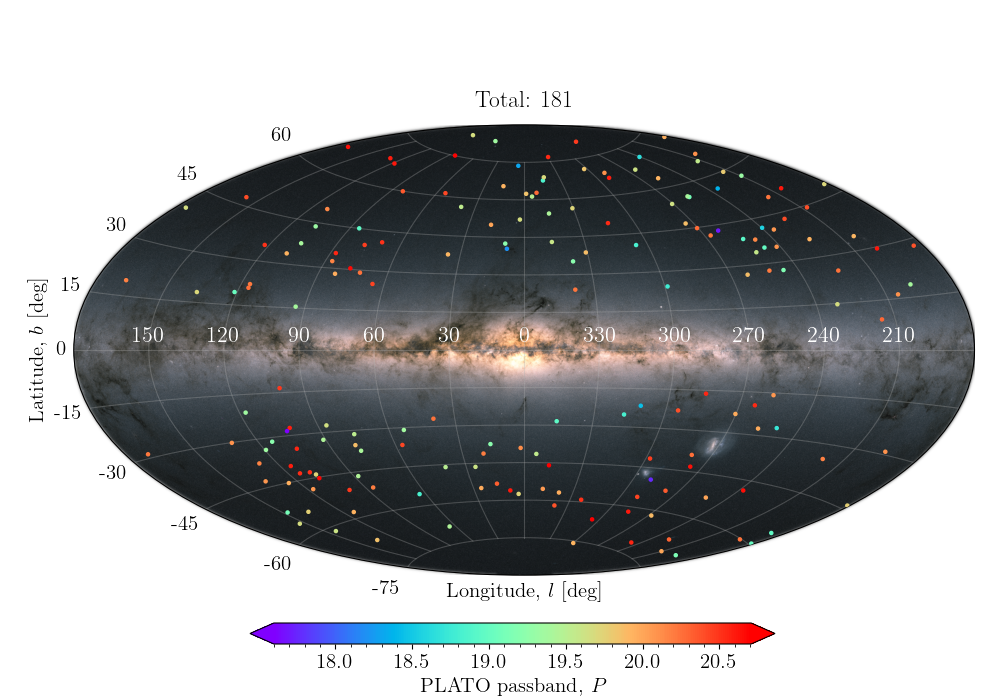

In [24]:
# Plot all candidates
fig, ax = pt.drawStarsInSkyAitoff(
    df_gasp_cand.ra, df_gasp_cand.dec, 
    column=df_gasp_cand.mean_mag_g_fov,
    title=f'Total: {df_gasp_cand.shape[0]}',
    fs=15, ms=5, figsize=(10,7))
# fig.savefig(f'{fdir}/aitoff_gasp_smbhb.png', bbox_inches='tight', dpi=300)

In [25]:
# Add candidates to dc
dc['gaiaDR3'] = df_gasp_cand.gaia_dr3_id
dc['l']       = df_gasp_cand.l
dc['b']       = df_gasp_cand.b
dc['ra']      = df_gasp_cand.ra
dc['dec']     = df_gasp_cand.dec
dc['mag']     = df_gasp_cand.mean_mag_g_fov
dc['ref']     = 'gasp'

#### *Canditates within PLATO catalogue* 

In [28]:
# Cross-match with PLATO catalogues
dt_gasp_cand = dt[dt['source_gaia_dr3'].isin(df_gasp_cand['gaia_dr3_id'])]
dx_gasp_cand = df_gasp_cand[df_gasp_cand['gaia_dr3_id'].isin(dt['source_gaia_dr3'])]
dt_gasp_cand

,ncam,source_gaia_dr3,ra,dec,l,Pmag,b,Gmag,BP_RP,Ag,...,z,z_err,period,period_std,log_B_PR,log_B_PR_std,ncon,SPR,rOA,NSR
4695,12,1429287810993935488,241.838319,55.258723,85.45469,18.805931,45.03819,18.959127,0.469072,0.0039,...,1.186849,0.079946,NaN,NaN,NaN,NaN,4.0,0.001262,15.928705,16424.942824


#### *Candidates visually within the LOPs*

In [29]:
# Candidates that overlap with the LOPs
targets = [74, 78, 81, 84, 85, 88, 100, 101, 105, 106, 114, 115, 116, 117, 118, 168, 170, 171, 177, 178]
dx_gasp_cand = df_gasp_cand.loc[targets].sort_values(by='mean_mag_g_fov')

# Best candidates
dx_gasp_cand_m19 = dx_gasp_cand[(dx_gasp_cand.mean_mag_g_fov < 19)]
dx_gasp_cand_m19

,gaia_dr3_id,log_bf_PR,log_bf_PR_std,period,period_std,ra,dec,bp_rp,mean_mag_g_fov,quaia_unwise_id,...,CatNorth_PS1_id,AllWISE,AllWISE_R90_id,AllWISE_C75_id,Milliquas_v65_id,SDSS_DR14Q_id,LQAC_v5,Gaia_unWISE_id,l,b
118,5572100182520281856,3.316525,1.398944,480.574442,11.235353,90.300009,-42.976020,0.669630,18.716946,0910m425o0004715,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0910m425o0004715,249.727481,-26.900020
101,1429287810993935488,3.321774,2.205833,518.019438,11.685371,241.838319,55.258723,0.469072,18.950869,2425p545o0036954,...,1.743124e+17,J160721.19+551531.4,J160721.19+551531.4,J160721.19+551531.4,SDSS J160721.20+551531.4,160721.20+551531.4,LQAC_241+055_012,2425p545o0036954,85.454693,45.038191


In [30]:
# Start main candidate list
df0 = pd.DataFrame({'ref':'GASP', 
                    'ra':dx_gasp_cand.ra, 
                    'dec':dx_gasp_cand.dec, 
                    'mag':dx_gasp_cand.mean_mag_g_fov}
                  )

<IPython.core.display.Javascript object>


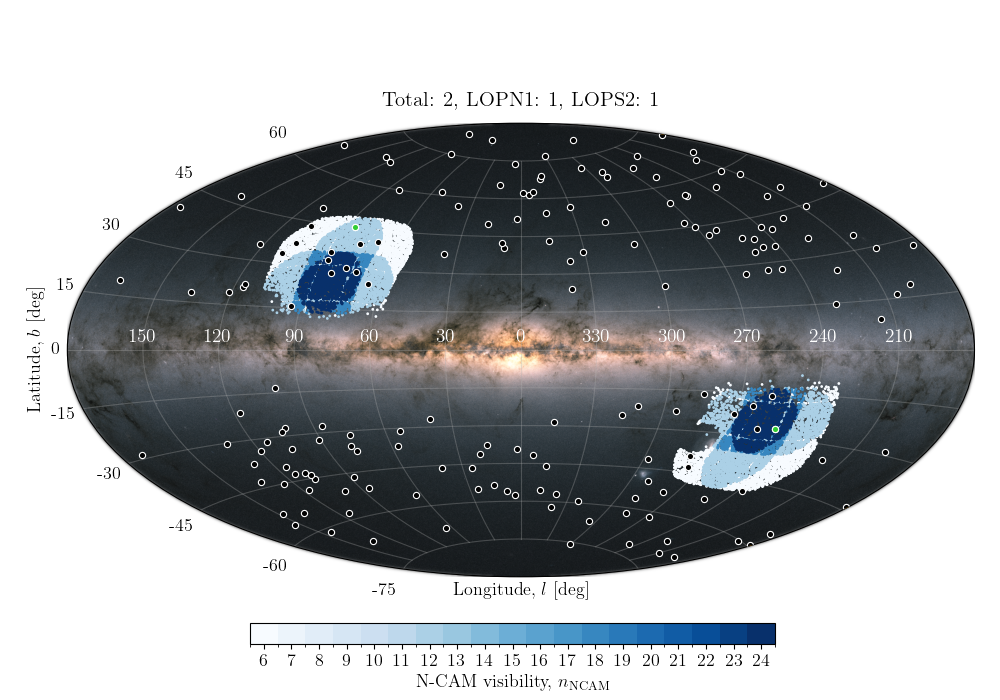

In [32]:
# Plot candidates in sky
fig, ax = bh.plot_aitoff(dt, df_gasp_cand, dx_gasp_cand, dx_gasp_cand_m19)

### 2.2 Candidates from AIFU (Horlaville+2025)

In [26]:
# Load data
df_aifu = pd.read_csv(f'{ddir}/aifu_horlaville2025.csv')

# Add Galactic coordinates
gal_aifu = SkyCoord(df_aifu.ra, df_aifu.dec, frame='icrs', unit=u.deg).galactic
df_aifu['l'] = gal_aifu.l.deg
df_aifu['b'] = gal_aifu.b.deg
df_aifu.head()

,Name,source_gaia_dr3,ra,dec,Gmag,Rank,D_Mpc,Survey,log_M_bh,log_h_0,LDA,h_norm,LDA_norm,Score,Profile,l,b
0,NGC4073,3891772263220977408,181.112749,1.896003,20.091410,1,91.5,MASSIVE,10.25,-13.04,4.08,0.98,0.99,0.99,C,276.908084,62.369710
1,NGC1016,2502292927842652800,39.581540,2.119301,20.193127,2,95.2,MASSIVE,10.25,-13.06,3.86,0.98,0.97,0.97,C,168.539989,-51.034946
2,NGC2832,0,139.945221,33.749742,NaN,3,105.2,MASSIVE,10.30,-13.02,3.62,0.99,0.94,0.97,C,191.092816,44.391434
3,NGC4486,3907709439453756032,187.705927,12.391125,16.838953,4,17.2,ATLAS3D,9.72,-13.20,4.03,0.93,0.98,0.96,C,283.777739,74.491155
4,NGC1060,0,40.812688,32.425011,NaN,5,67.4,MASSIVE,10.00,-13.32,4.21,0.90,1.00,0.95,NaN,148.767244,-24.777228


<IPython.core.display.Javascript object>


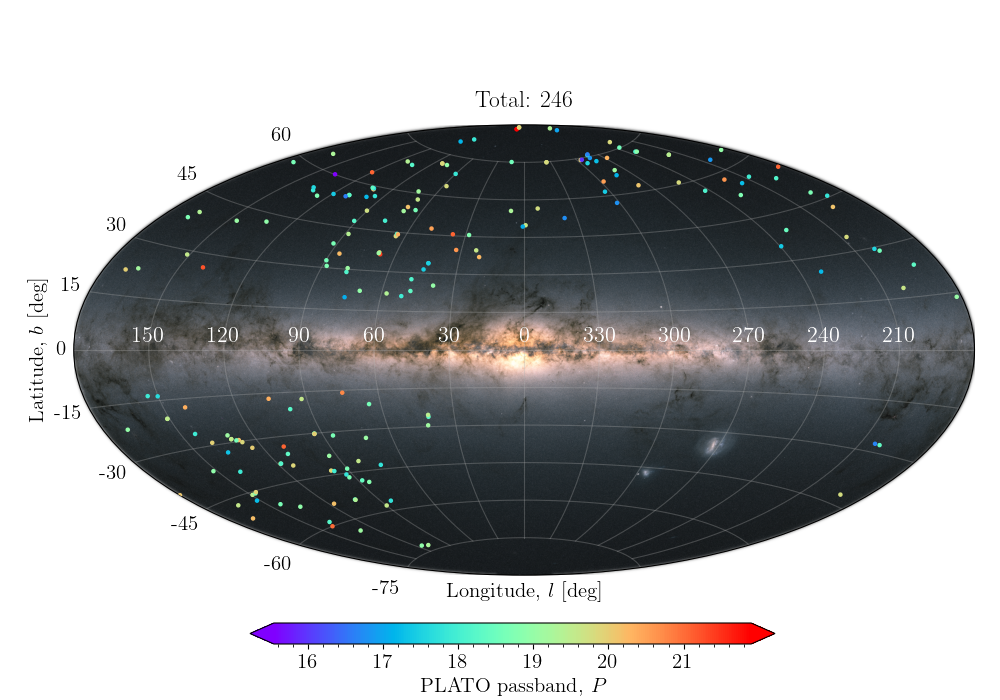

In [27]:
# Plot all candidates
fig, ax = pt.drawStarsInSkyAitoff(
    df_aifu.ra, df_aifu.dec, column=df_aifu.Gmag,
    title=f'Total: {df_aifu.shape[0]}',
    fs=15, ms=5, figsize=(10,7))
# fig.savefig(f'{fdir}/aitoff_aifu_all.png', bbox_inches='tight', dpi=300)

In [28]:
# Add candidates to dc
dx = pd.DataFrame()
dx['gaiaDR3'] = df_aifu.source_gaia_dr3
dx['l']       = df_aifu.l
dx['b']       = df_aifu.b
dx['ra']      = df_aifu.ra
dx['dec']     = df_aifu.dec
dx['mag']     = df_aifu.Gmag
dx['ref']     = 'aifu'
dc = pd.concat([dc, dx])

#### Candidates in LOPs

In [35]:
# Check overlapping candidates
dt_aifu = dt[dt['source_gaia_dr3'].isin(df_aifu['source_gaia_dr3'])]
dx_aifu = df_aifu[df_aifu['source_gaia_dr3'].isin(dt['source_gaia_dr3'])]
dt_aifu

,ncam,source_gaia_dr3,ra,dec,l,Pmag,b,Gmag,BP_RP,Ag,...,z,z_err,period,period_std,log_B_PR,log_B_PR_std,ncon,SPR,rOA,NSR


In [32]:
# No overlapping candidates but the following sources are within the LOPN1
dex_aifu = np.array([48, 51, 82, 86, 89, 92, 95, 96, 97, 99, 111, 136, 173, 182, 194, 219, 242])
dx_aifu = df_aifu.loc[dex_aifu].sort_values(by='Gmag')

# Make cuts and alter data frame
dt_aifu = dx_aifu[(dx_aifu.Gmag < 19) & (dx_aifu.LDA > 3)]
dt_aifu = dt_aifu.reset_index(drop=True)
dt_aifu

,Name,source_gaia_dr3,ra,dec,Gmag,Rank,D_Mpc,Survey,log_M_bh,log_h_0,LDA,h_norm,LDA_norm,Score,Profile,l,b
0,NGC6703,2118960907628642688,281.828404,45.550632,17.083054,83,25.9,ATLAS3D,8.48,-15.45,3.91,0.25,0.97,0.71,P,74.893839,19.677648
1,NGC6515,1364561721838534272,269.354973,50.728120,18.140308,98,106.2,CALIFA,8.84,-15.46,3.37,0.25,0.92,0.67,NaN,78.213626,28.983514
2,NGC6411,1435958685478118400,263.886853,60.813399,18.607180,100,61.3,CALIFA,8.65,-15.53,3.24,0.23,0.91,0.66,NaN,89.730686,32.628741


In [33]:
# Add cand to main list
dx0 = pd.DataFrame({'ref':'AIFU', 
                    'ra':dt_aifu.ra, 
                    'dec':dt_aifu.dec, 
                    'mag':dt_aifu.Gmag}
                  )
df0 = pd.concat([df0, dx0])

In [34]:
# Fetch Gaia information about candidates
dq_aifu = bh.fetch_gaia_info(dt_aifu)
# dq_aifu.insert(0, 'source', dt_aifu.Name)
# dt_aifu.insert(4, 'Pmag', ut.passbandConversionG2P(dt_aifu_query.Gmag, dt_aifu_query.BP_RP))
# dt_aifu.insert(6, 'BP_RP', dt_aifu_query.BP_RP)
# dt_aifu['ncam'] = np.array([12, 6, 24, 6, 6, 12, 12, 12, 18])
dq_aifu

,source_gaia_dr3,ra,dec,l,b,Gmag,BP_RP,Ag,plx,plx_err,pm,pmra,pmra_error,pmdec,pmdec_error,ruwe
0,2118960907628642688,281.828404,45.550632,74.893833,19.677648,17.083054,1.455188,NaN,-0.209649,0.246149,0.182027,0.150646,0.265103,0.102174,0.316431,1.742362
1,1364561721838534272,269.354973,50.728120,78.213621,28.983514,18.140308,1.392138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1435958685478118400,263.886853,60.813399,89.730682,32.628740,18.607180,1.392271,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<IPython.core.display.Javascript object>


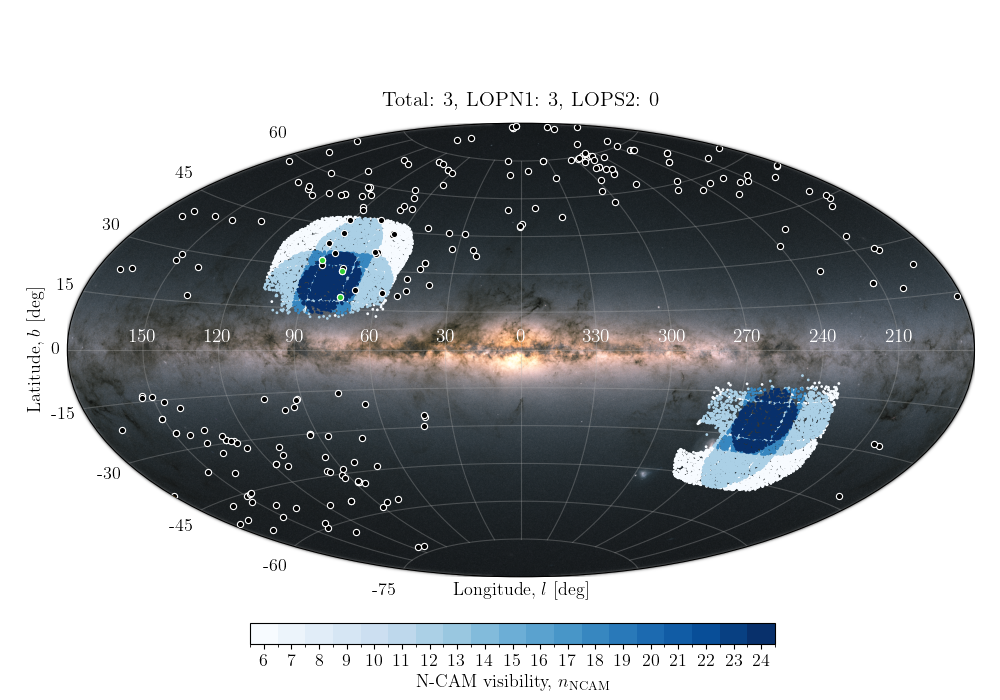

In [35]:
# Plot candidates in sky
fig, ax = bh.plot_aitoff(dt, df_aifu, dx_aifu, dt_aifu)

### 2.2. Candidates from the CRTS (Graham+2015) 

In [29]:
# Load Quaia catalogue
filename = f'{ddir}/crts_graham2015.csv'
df_crts = pd.read_csv(filename)
df_crts.head()

,No.,Object Name,RA-s,Dec-s,RA,Dec,Object Type,cz (Velocity),Redshift (z),z flag,Reference,Note,Photometry,Position,Redshift,Diameter,Distances,Classification,Images,Spectra
0,1,LBQS 0009-0138,00h12m10.8907s,-01d22m07.630s,3.045378,-1.368786,QSO,599285.123542,1.999000,SUN,60,0,20,11,8,0,0,1,0,0
1,2,LBQS 0020+0058,00h23m03.1572s,+01d15m33.607s,5.763155,1.259335,QSO,218530.114750,0.728938,SUN,66,0,55,22,31,4,0,1,0,1
2,3,MRK 0504,17h01m07.7809s,+29d24m24.588s,255.282421,29.406830,G,10823.107319,0.036102,SUN,136,3,62,21,20,10,0,5,2,1
3,4,FBQS J0200+0125,02h00m03.9391s,+01d25m11.952s,30.016413,1.419987,QSO,350757.163868,1.170000,SUN,47,0,43,13,3,0,0,1,0,0
4,5,[HB89] 0246+009,02h49m28.8674s,+01d09m24.559s,42.370281,1.156822,QSO,285784.733346,0.953275,SLS,52,0,50,14,24,8,0,1,0,2


In [30]:
# Fetch Gaia information for candidates
dq_crts = bh.fetch_gaia_info(df_crts, NED=True)
dq_crts.head()

100%|██████████████████████████████████████████████████| 111/111 [11:53<00:00,  6.43s/it]            


,source,source_gaia_dr3,ra,dec,l,b,Gmag,BP_RP,Ag,plx,plx_err,pm,pmra,pmra_error,pmdec,pmdec_error,ruwe,z
0,LBQS 0009-0138,2544750431910682240,3.045418,-1.368774,101.219051,-62.573954,17.388350,0.620436,0.0016,-0.003557,0.110065,0.149037,0.093500,0.148184,0.116059,0.089669,0.942214,1.999000
1,LBQS 0020+0058,2547022091653816064,5.763146,1.259344,108.266392,-60.801604,18.173792,0.361698,0.0009,0.039268,0.136403,0.247724,-0.125657,0.166791,-0.213489,0.148137,0.949413,0.728938
2,MRK 0504,1309563295515831808,255.282411,29.406828,51.079327,35.649002,16.658611,1.072939,NaN,-0.016493,0.050889,0.189918,-0.017558,0.052126,-0.189105,0.063688,1.096174,0.036102
3,FBQS J0200+0125,2508348178894931072,30.016400,1.420007,155.730776,-57.016039,17.903145,0.488579,0.0118,-0.118309,0.158830,0.323819,0.313600,0.180518,0.080706,0.124687,1.013237,1.170000
4,[HB89] 0246+009,2499165397082525568,42.370262,1.156853,172.831862,-49.921207,18.589943,0.390921,0.0014,-0.334021,0.195003,0.416445,-0.150080,0.207406,-0.388461,0.194389,1.005635,0.953275


<IPython.core.display.Javascript object>


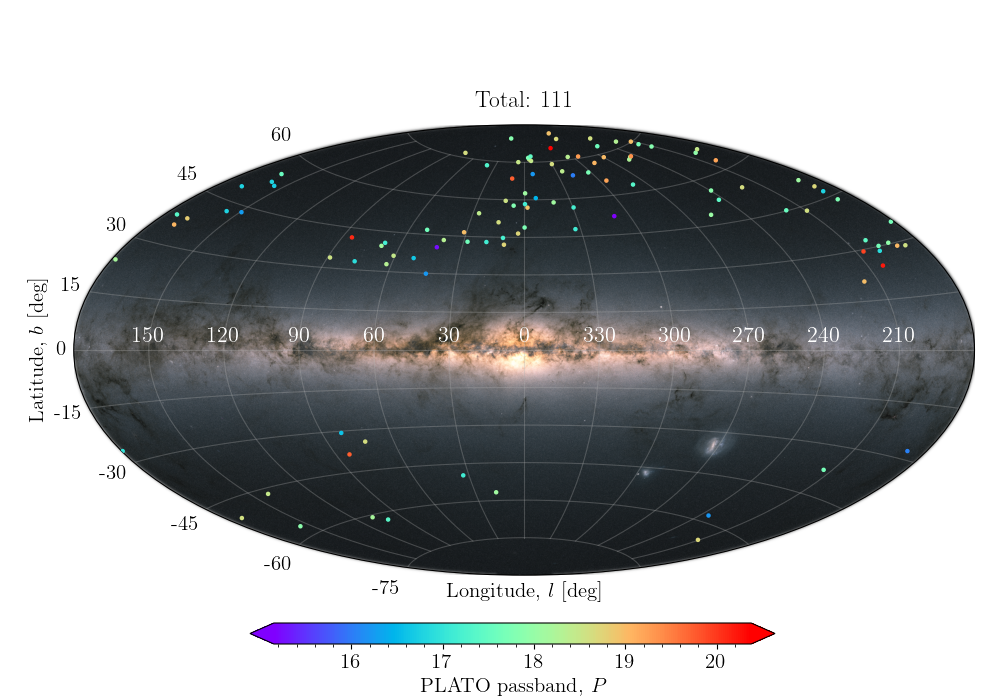

In [31]:
# Plot all candidates
fig, ax = pt.drawStarsInSkyAitoff(
    dq_crts.ra, dq_crts.dec, column=dq_crts.Gmag,
    title=f'Total: {dq_crts.shape[0]}',
    fs=15, ms=5, figsize=(10,7));
# fig.savefig(f'{fdir}/aitoff_crts_smbhb.png', bbox_inches='tight', dpi=300)

In [32]:
# Add candidates to dc
dx = pd.DataFrame()
dx['gaiaDR3'] = dq_crts.source_gaia_dr3
dx['l']       = dq_crts.l
dx['b']       = dq_crts.b
dx['ra']      = dq_crts.ra
dx['dec']     = dq_crts.dec
dx['mag']     = dq_crts.Gmag
dx['ref']     = 'crts'
dc = pd.concat([dc, dx])

#### Candidates within LOPs

In [58]:
# Match to original catalogues
dt_crts = dt[dt['source_gaia_dr3'].isin(dq_crts['source_gaia_dr3'])]
dx_crts = dq_crts[dq_crts['source_gaia_dr3'].isin(dt['source_gaia_dr3'])]

# Add missing target
dx_crts = dx_crts.append(dq_crts.loc[41])
dx_crts.source_gaia_dr3 = dx_crts.source_gaia_dr3.astype(int)
dt_crts = dt_crts.append(dq_crts.loc[41])
dt_crts.source_gaia_dr3 = dt_crts.source_gaia_dr3.astype(int)

# Add columns and missing parameters
dt_crts.iloc[1].z = dx_crts.iloc[1].z
dt_crts.iloc[1].z = dx_crts.iloc[1].z

# Sort after magnitude
dx_crts = dx_crts.sort_values(by='Gmag')
dt_crts = dt_crts.sort_values(by='Gmag')
dt_crts

,ncam,source_gaia_dr3,ra,dec,l,Pmag,b,Gmag,BP_RP,Ag,...,z_err,period,period_std,log_B_PR,log_B_PR_std,ncon,SPR,rOA,NSR,source
5211,24.0,1366547336756487552,262.765351,50.126468,76.990185,16.764988,33.091381,16.916212,0.462244,1.5746,...,0.145035,NaN,NaN,NaN,NaN,5.0,3.181445e-03,12.092318,2828.729857,NaN
41,NaN,1357394284706647936,251.219629,43.131192,67.860324,NaN,40.727249,17.161455,0.828278,0.2863,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WISEA J164452.71+430752.2
2677,12.0,1358975275051816320,252.903182,43.794805,68.764545,17.924938,39.520830,18.127722,0.651186,0.0054,...,0.064639,NaN,NaN,NaN,NaN,11.0,2.827254e-03,14.541406,10100.251571,NaN
3059,12.0,1337517687160711296,260.976252,37.811480,62.229102,18.191486,32.793426,18.317549,0.377438,0.0033,...,0.052221,NaN,NaN,NaN,NaN,10.0,1.653603e-03,14.708158,13225.720682,NaN
866,6.0,1339480865172159872,256.567674,37.157495,60.723208,18.280132,36.128474,18.471382,0.606861,0.0088,...,0.068232,NaN,NaN,NaN,NaN,8.0,9.435256e-03,12.409784,15876.557178,NaN
5018,18.0,1435818566465103360,261.737327,60.063475,88.897025,18.453881,33.724148,18.559086,0.310074,0.0008,...,0.051498,NaN,NaN,NaN,NaN,2.0,6.396713e-08,10.724053,11070.110809,NaN


<IPython.core.display.Javascript object>


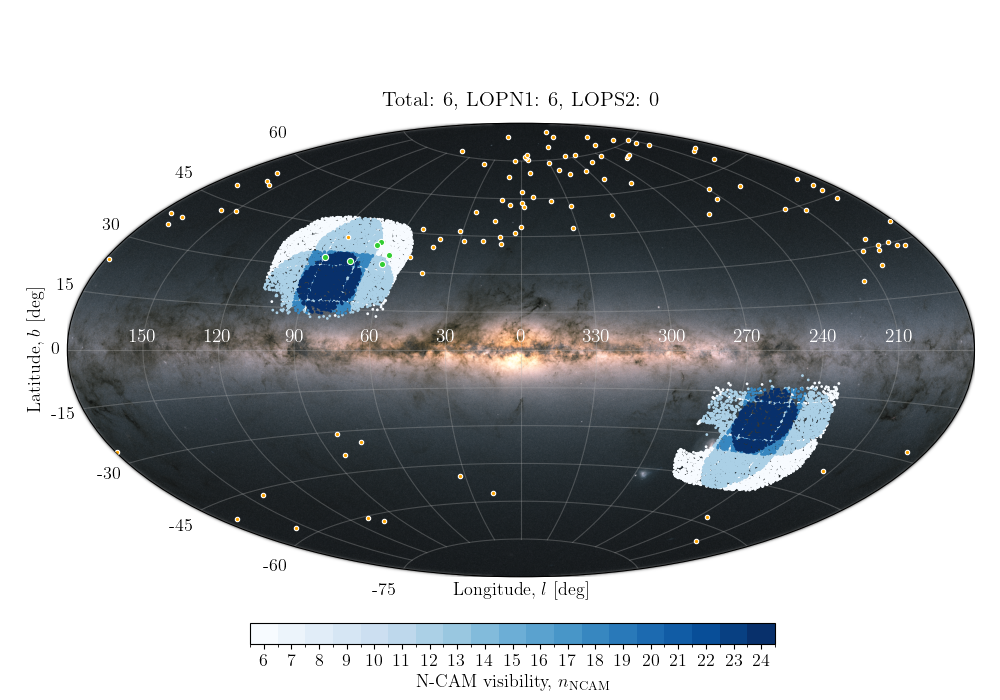

In [59]:
# Plot candidates in sky
fig, ax = bh.plot_aitoff(dt, df_crts, False, dt_crts, NED=True)

### 2.3 Candidates from PTF (Charisi+2016)

In [33]:
# Load Quaia catalogue
filename = f'{ddir}/table_ptf_charisi2016.csv'
df_ptf = pd.read_csv(filename)

# Remove non-significant candidates
df_ptf = df_ptf.sort_values(by='RA').reset_index(drop=True)
num = np.array([11, 39, 5, 40, 3, 24, 25, 26, 7, 29, 31, 28, 32, 42, 34, 38, 50])
for n in num: df_ptf = df_ptf[df_ptf['No.'] != n]
df_ptf = df_ptf.reset_index(drop=True)
df_ptf.head()

,No.,Object Name,RA-s,Dec-s,RA,Dec,Object Type,cz (Velocity),Redshift (z),z flag,Reference,Note,Photometry,Position,Redshift,Diameter,Distances,Classification,Images,Spectra
0,1,UM 269,00h43m19.7396s,+00d51m15.325s,10.832248,0.854257,QSO,92405.029329,0.308230,SUN,102,0,73,31,34,8,0,1,0,1
1,10,WISEA J005158.83-002053.9,00h51m58.8333s,-00d20m53.985s,12.995139,-0.348329,QSO,313882.703526,1.047000,SLS,40,0,49,19,28,8,0,1,0,2
2,18,WISEA J005453.30-003258.5,00h54m53.3073s,-00d32m58.597s,13.722114,-0.549611,QSO,288160.510630,0.961200,SLS,12,0,23,6,5,4,0,0,0,0
3,19,WISEA J024442.77-004223.2,02h44m42.7749s,-00d42m23.276s,41.178229,-0.706466,QSO,188273.599899,0.628013,SLS,32,0,35,16,21,4,0,0,0,0
4,8,SDSS J095344.80+010354.8,09h53m44.8006s,+01d03m54.857s,148.436669,1.065238,QSO,298053.661744,0.994200,UUN,14,0,18,5,4,4,0,1,0,1


In [35]:
# Fetch Gaia information for candidates
dq_ptf = bh.fetch_gaia_info(df_ptf, NED=True)
dq_ptf.head()

100%|██████████████████████████████████████████████████| 33/33 [03:19<00:00,  6.05s/it]              


,source,source_gaia_dr3,ra,dec,l,b,Gmag,BP_RP,Ag,plx,plx_err,pm,pmra,pmra_error,pmdec,pmdec_error,ruwe,z
0,UM 269,2549329996623794304,10.832257,0.854296,118.618271,-61.949518,18.181227,0.819365,NaN,0.211228,0.168518,0.358606,0.358499,0.227880,-0.008766,0.246045,1.075321,0.308230
1,WISEA J005158.83-002053.9,2536722382120108416,12.995139,-0.348378,123.233000,-63.219811,19.197313,0.596869,NaN,0.236362,0.330468,0.497819,-0.009124,0.476265,-0.497735,0.441232,1.097406,1.047000
2,WISEA J005453.30-003258.5,2536046006374930816,13.722121,-0.549527,124.859258,-63.408364,20.018631,0.773191,NaN,0.354253,0.564620,1.353309,-0.942875,0.679837,-0.970790,0.605145,0.995311,0.961200
3,WISEA J024442.77-004223.2,2498414224481651968,41.178247,-0.706464,173.475638,-52.095772,19.668089,0.526894,NaN,-0.354204,0.355570,0.861797,0.514426,0.438239,0.691419,0.478042,1.111833,0.628013
4,SDSS J095344.80+010354.8,3834563913019003648,148.436699,1.065196,236.759303,40.090103,20.285995,0.374981,NaN,0.095955,0.840649,1.488469,-1.089675,1.122856,1.013976,1.202890,1.112185,0.994200


<IPython.core.display.Javascript object>


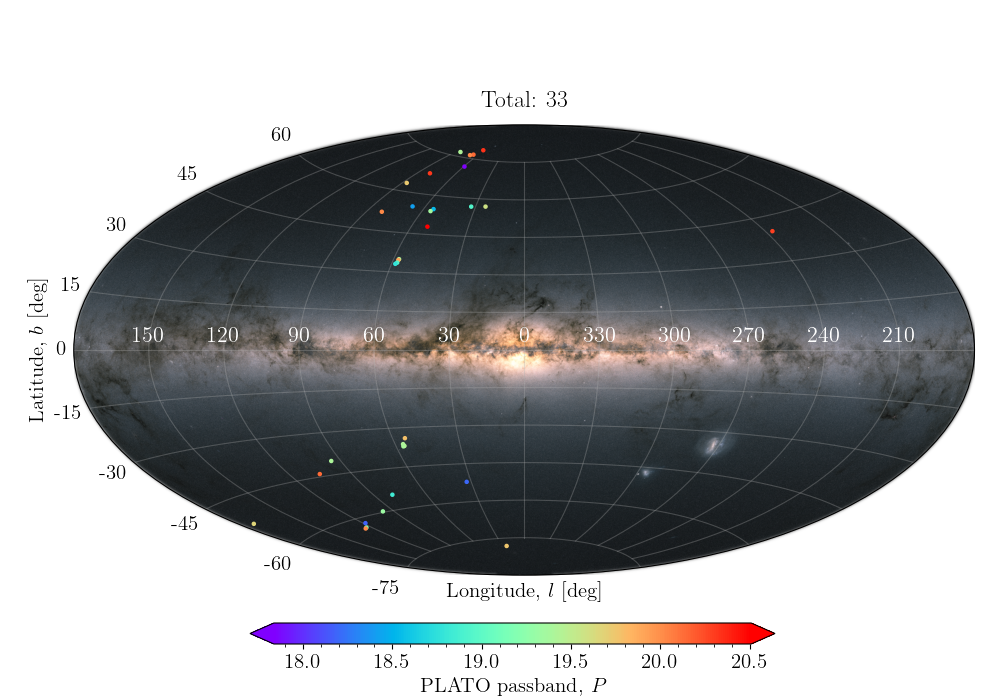

In [36]:
# Plot all candidates
fig, ax = pt.drawStarsInSkyAitoff(
    dq_ptf.ra, dq_ptf.dec, column=dq_ptf.Gmag,
    title=f'Total: {dq_ptf.shape[0]}',
    fs=15, ms=5, figsize=(10,7));
# fig.savefig(f'{fdir}/aitoff_crts_smbhb.png', bbox_inches='tight', dpi=300)

In [37]:
# Add candidates to dc
dx = pd.DataFrame()
dx['gaiaDR3'] = dq_ptf.source_gaia_dr3
dx['l']       = dq_ptf.l
dx['b']       = dq_ptf.b
dx['ra']      = dq_ptf.ra
dx['dec']     = dq_ptf.dec
dx['mag']     = dq_ptf.Gmag
dx['ref']     = 'ptf'
dc = pd.concat([dc, dx])

#### Candidates within LOPs

In [ ]:
# Match to original catalogues
dt_ptf = dt[dt['source_gaia_dr3'].isin(dq_ptf['source_gaia_dr3'])]
dx_ptf = dq_ptf[dq_ptf['source_gaia_dr3'].isin(dt['source_gaia_dr3'])]
dt_ptf

In [ ]:
df_ptf.iloc[21]

In [ ]:
# Add cand to main list
dx0 = pd.DataFrame({'ref':'PTF', 
                    'ra':dt_ptf.ra, 
                    'dec':dt_ptf.dec, 
                    'mag':dt_ptf.Gmag}
                  )
df0 = pd.concat([df0, dx0])

In [ ]:
# Plot candidates in sky
fig, ax = bh.plot_aitoff(dt, df_ptf, False, dt_ptf, NED=True)

### 2.4 Candidates from ZTF (Chen+2024) 

In [38]:
# Load Quaia catalogue
filename = f'{ddir}/table_ztf_chen2024.csv'
df_ztf = pd.read_csv(filename)
df_ztf = df_ztf[df_ztf['Object Type'] == 'QSO']
df_ztf

,No.,Object Name,RA-s,Dec-s,RA,Dec,Object Type,cz (Velocity),Redshift (z),z flag,Reference,Note,Photometry,Position,Redshift,Diameter,Distances,Classification,Images,Spectra
0,1,LBQS 0019-0000,00h22m09.9565s,+00d16m29.351s,5.541486,0.274820,QSO,172328.481475,0.574826,SLS,64,0,85,24,29,13,0,1,0,1
1,2,WISEA J004039.78+150321.2,00h40m39.7883s,+15d03m21.240s,10.165785,15.055900,QSO,264980.956501,0.883881,SLS,31,0,32,15,14,4,0,0,0,1
2,3,WISEA J003718.87+143222.0,00h37m18.8711s,+14d32m22.026s,9.328630,14.539452,QSO,239347.073469,0.798376,SLS,32,0,37,10,18,8,0,1,0,1


In [39]:
# Missing magnitude hence fetch Gaia info
dq_ztf = bh.fetch_gaia_info(df_ztf, NED=True)
dq_ztf.head()

100%|██████████████████████████████████████████████████| 3/3 [00:18<00:00,  6.01s/it]                


,source,source_gaia_dr3,ra,dec,l,b,Gmag,BP_RP,Ag,plx,plx_err,pm,pmra,pmra_error,pmdec,pmdec_error,ruwe,z
0,LBQS 0019-0000,2546805792804731136,5.541486,0.274810,107.342593,-61.707751,18.180544,0.445017,0.0010,0.192554,0.143812,0.321096,0.283561,0.172395,-0.150652,0.120547,0.951310,0.574826
1,WISEA J004039.78+150321.2,2779749906813051136,10.165804,15.055890,119.062791,-47.734898,18.291025,0.766127,0.0050,-0.044766,0.158560,0.192882,0.036610,0.170272,-0.189375,0.117502,1.006961,0.883881
2,WISEA J003718.87+143222.0,2779625215322558080,9.328609,14.539433,117.801429,-48.191574,18.659313,0.575275,0.0038,-0.028162,0.207067,0.083738,0.044231,0.248322,-0.071103,0.180571,1.004965,0.798376


<IPython.core.display.Javascript object>


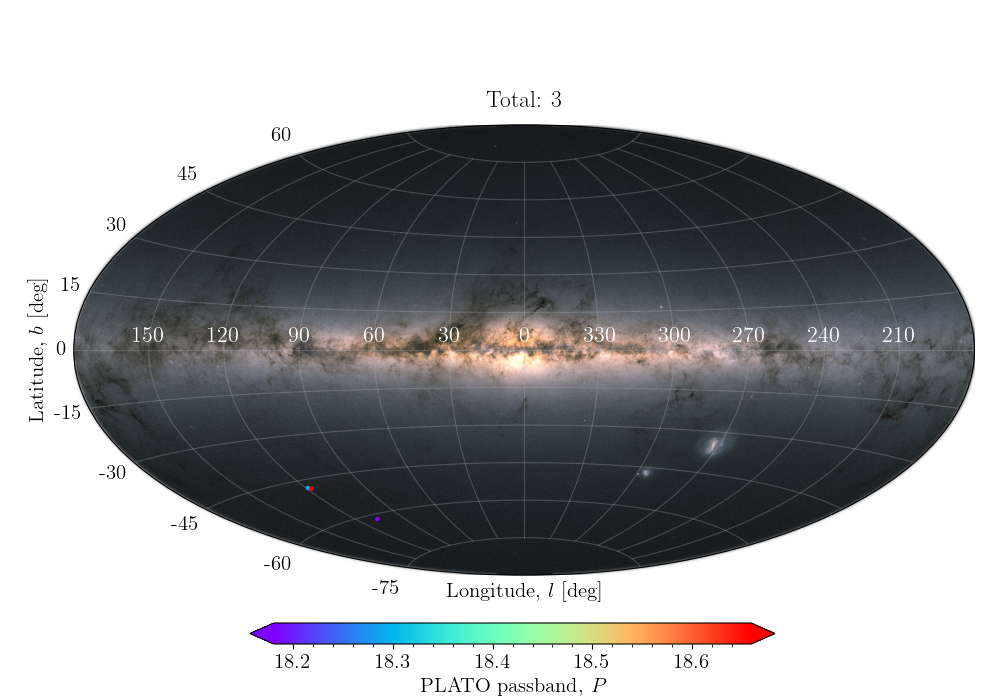

In [40]:
# Plot all candidates
fig, ax = pt.drawStarsInSkyAitoff(
    dq_ztf.ra, dq_ztf.dec, column=dq_ztf.Gmag,
    title=f'Total: {dq_ztf.shape[0]}',
    fs=15, ms=5, figsize=(10,7));
# fig.savefig(f'{fdir}/aitoff_crts_smbhb.png', bbox_inches='tight', dpi=300)

In [41]:
# Add candidates to dc
dx = pd.DataFrame()
dx['gaiaDR3'] = dq_ztf.source_gaia_dr3
dx['l']       = dq_ztf.l
dx['b']       = dq_ztf.b
dx['ra']      = dq_ztf.ra
dx['dec']     = dq_ztf.dec
dx['mag']     = dq_ztf.Gmag
dx['ref']     = 'ztf'
dc = pd.concat([dc, dx])

No PTF candidates within LOPs!

### 2.5 Candidate from Pan-STARS1 (Liu+2019) 

In [42]:
df_pan = sq.simbadQuery('PSO J185.8689+46.9752')

# Add Galactic coordinates
gal_pan = SkyCoord(df_pan.ra, df_pan.dec, frame='icrs', unit=u.deg).galactic
df_pan['l'] = gal_pan.l.deg
df_pan['b'] = gal_pan.b.deg
df_pan

,dis,gaiaDR3,ra,dec,Gmag,BP_RP,plx,plxe,pmra,pmdec,ruwe,teff,logg,Pmag,l,b
0,0.0,1545324010421021952,185.868936,46.975219,20.405256,0.677952,-1.064516,0.73807,-0.085484,-0.057707,0.960642,NaN,NaN,20.195675,136.586706,69.404737


In [43]:
dx = pd.DataFrame()
dx['gaiaDR3'] = df_pan.gaiaDR3
dx['l']       = df_pan.l
dx['b']       = df_pan.b
dx['ra']      = df_pan.ra
dx['dec']     = df_pan.dec
dx['mag']     = df_pan.Gmag
dx['ref']     = 'pan'
dc = pd.concat([dc, dx])

### 2.6 Candidate from Kepler (Hu+2020)

In [44]:
df_spikey = sq.simbadQuery('KIC 011606854', radius=0.01)
df_spikey

,dis,gaiaDR3,ra,dec,Gmag,BP_RP,plx,plxe,pmra,pmdec,ruwe,teff,logg,Pmag
0,0.0,2132637943222806784,289.689915,49.632232,17.750565,0.348852,0.030644,0.077436,0.016816,0.033494,1.028128,7461.581055,4.3967,17.633261


In [45]:
dt_spikey = dt[dt['source_gaia_dr3'].isin(df_spikey['gaiaDR3'])]
dt_spikey

,ncam,source_gaia_dr3,ra,dec,l,Pmag,b,Gmag,BP_RP,Ag,...,z,z_err,period,period_std,log_B_PR,log_B_PR_std,ncon,SPR,rOA,NSR
5363,24,2132637943222806784,289.689915,49.632232,80.891221,17.63326,16.192104,17.750565,0.348852,0.0012,...,0.920141,0.080362,NaN,NaN,NaN,NaN,29.0,0.022962,11.761182,4569.139569


In [46]:
dx = pd.DataFrame()
dx['gaiaDR3'] = dt_spikey.source_gaia_dr3
dx['l']       = dt_spikey.l
dx['b']       = dt_spikey.b
dx['ra']      = dt_spikey.ra
dx['dec']     = dt_spikey.dec
dx['mag']     = dt_spikey.Gmag
dx['ref']     = 'spikey'
dc = pd.concat([dc, dx])

In [47]:
from uncertainties import ufloat
T = ufloat(1.144, 0.03) * ut.year() / 86400 
z = ufloat(dt_spikey.z.to_numpy(), dt_spikey.z_err.to_numpy())
P = T * (1 + z)
P

802.3061211614199+/-39.62503852921858

In [48]:
df_OJ287 = sq.simbadQuery('OJ 287', radius=0.01)
gal = SkyCoord(df_OJ287.ra, df_OJ287.dec, frame='icrs', unit=u.deg).galactic
dx = pd.DataFrame()
dx['gaiaDR3'] = df_OJ287.gaiaDR3
dx['l']       = gal_pan.l.deg
dx['b']       = gal_pan.b.deg
dx['ra']      = df_OJ287.ra
dx['dec']     = df_OJ287.dec
dx['mag']     = df_OJ287.Gmag
dx['ref']     = 'OJ287'
dc = pd.concat([dc, dx])

In [49]:
df_PG1302 = sq.simbadQuery('PG 1302-102', radius=0.01)
gal = SkyCoord(df_PG1302.ra, df_PG1302.dec, frame='icrs', unit=u.deg).galactic
dx = pd.DataFrame()
dx['gaiaDR3'] = df_PG1302.gaiaDR3
dx['l']       = gal_pan.l.deg
dx['b']       = gal_pan.b.deg
dx['ra']      = df_PG1302.ra
dx['dec']     = df_PG1302.dec
dx['mag']     = df_PG1302.Gmag
dx['ref']     = 'PG1302'
dc = pd.concat([dc, dx])

### 2.7 Create final catalogue

In [50]:
dc = dc.reset_index(drop=True)
dc.to_feather(ddir / 'source_catalogue_candidates.ftr')
dc = pd.read_feather(ddir / 'source_catalogue_candidates.ftr')

In [ ]:
dc.ref.unique()

<IPython.core.display.Javascript object>


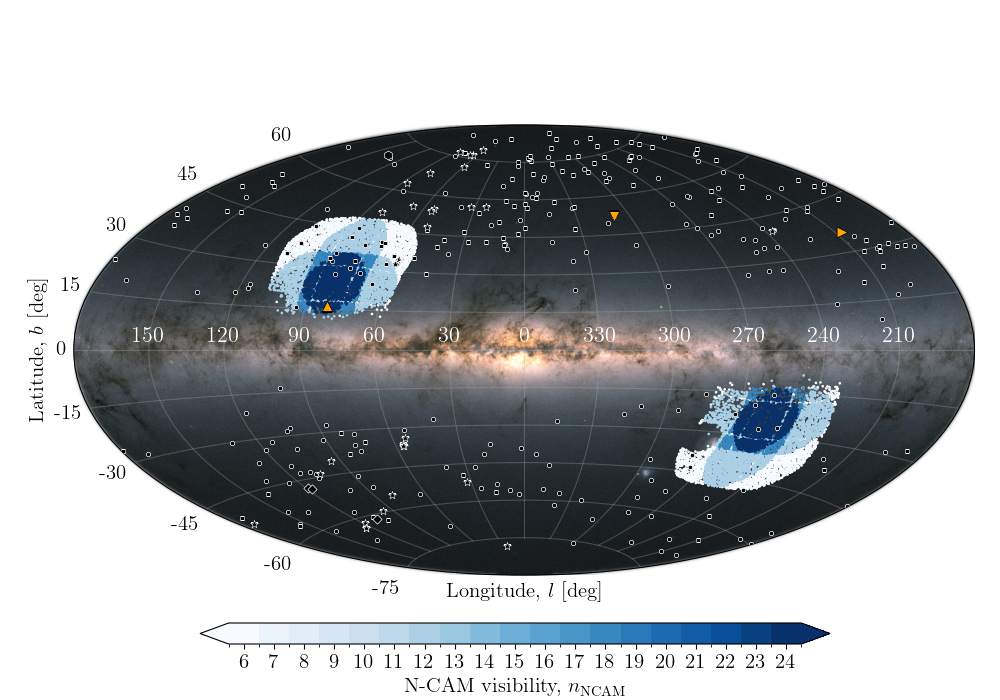

In [58]:
fig, ax = plt.subplots(figsize=(10,7))
axes = fig.add_subplot(111, projection='aitoff', facecolor='none')

s  = 10 
ms = 0.8
fs = 15
lw = 0.5
ec = 'w'
cmap = 'Purples'

# Plot Gaia image
skymap = plt.imread(f'{os.getenv("PLATO_PROJECT_HOME")}/docs/figures/gaiaDR3.png')
ax.imshow(skymap)

# Fetch custom discrete colorbar used by matplotlib
column = dt.ncam
cbins = np.arange(column.min(), column.max()+2, 1) 
ticks = cbins - 0.5
norm  = pt.discretizeColorbar(cbins=cbins, cmap='Blues')
gal = SkyCoord(dt.ra, dt.dec, frame='icrs', unit=u.deg).galactic
im = plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c=column, s=ms, cmap='Blues', norm=norm, zorder=3)

# Plot GASP candidates
dx = dc[dc.ref == 'gasp']
gal = SkyCoord(dx.ra, dx.dec, frame='icrs', unit=u.deg).galactic
plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c='k', 
            marker='o', s=10, ec=ec, lw=lw, zorder=3)

# Plot AIFU candidates
# dx = dc[dc.ref == 'aifu']
# gal = SkyCoord(dx.ra, dx.dec, frame='icrs', unit=u.deg).galactic
# plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c='k', 
#             marker='*', s=35, ec=ec, lw=lw-0.2, zorder=3)

# # Plot CRTS candidates
dx = dc[dc.ref == 'crts']
gal = SkyCoord(dx.ra, dx.dec, frame='icrs', unit=u.deg).galactic
plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c='k', 
            marker='s', s=11, ec=ec, lw=lw-0.1, zorder=3)

# Plot PTF candidates
dx = dc[dc.ref == 'ptf']
gal = SkyCoord(dx.ra, dx.dec, frame='icrs', unit=u.deg).galactic
plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c='k', 
            marker='*', s=35, ec=ec, lw=lw-0.1, zorder=3)

# Plot ZTF candidates
dx = dc[dc.ref == 'ztf']
gal = SkyCoord(dx.ra, dx.dec, frame='icrs', unit=u.deg).galactic
plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c='k', 
            marker='D', s=22, ec=ec, lw=lw, zorder=3)

# Plot ZTF candidates
dx = dc[dc.ref == 'pan']
gal = SkyCoord(dx.ra, dx.dec, frame='icrs', unit=u.deg).galactic
plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c='k', 
            marker='h', s=40, ec=ec, lw=lw, zorder=3)

# Official candidates: Spikey
dx = dc[(dc.ref == 'spikey')]
gal = SkyCoord(dx.ra, dx.dec, frame='icrs', unit=u.deg).galactic
plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c='orange', 
            marker='^', s=60, ec='k', lw=lw, zorder=3)
dx = dc[(dc.ref == 'OJ287')]
gal = SkyCoord(dx.ra, dx.dec, frame='icrs', unit=u.deg).galactic
plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c='orange', 
            marker='>', s=60, ec='k', lw=lw, zorder=3)
dx = dc[(dc.ref == 'PG1302')]
gal = SkyCoord(dx.ra, dx.dec, frame='icrs', unit=u.deg).galactic
plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c='orange', 
            marker='v', s=60, ec='k', lw=lw, zorder=3)


cbarax = fig.add_axes([0.2, 0.08, 0.63, 0.03])
cbar = plt.colorbar(im, orientation='horizontal', cax=cbarax, extend='both', 
                    ticks=ticks, boundaries=cbins, format='%1i')
cbar.set_label(r'N-CAM visibility, $n_{\rm NCAM}$', fontsize=fs) 
cbar.ax.tick_params(labelsize=fs)

# Change the tick labels so that they are 0->360, rather than -180->+180
tickLabels = np.array([150, 120, 90, 60, 30, 0, 330, 300, 270, 240, 210])
tickLabels = np.remainder(tickLabels+360, 360)
axes.set_xticklabels(tickLabels)

# Change y ticks and remove last to make space for title
tickLabels = np.array([-75, -60, -45, -30, -15, 0, 15, 30, 45, 60, ''])
axes.set_yticklabels(tickLabels)
axes.tick_params(axis='x', colors='w')

# Increase x and y tick labels
axes.xaxis.set_tick_params(labelsize=fs+1)
axes.yaxis.set_tick_params(labelsize=fs)

# Add axes labels
axes.set_xlabel(r'Longitude, $l$ [deg]', fontsize=fs)
axes.set_ylabel(r'Latitude, $b$ [deg]', fontsize=fs)

# Set grid and remore outer ticks (if set by default)
axes.grid(True, alpha=0.3)
ax.axis('off')
plt.draw()
plt.tight_layout()

# Save figure
fig.savefig(f'{fdir}/aitoff_plato_candidates.png', bbox_inches='tight', dpi=300)

In [ ]:
fig, ax = plt.subplots(figsize=(10,7))
axes = fig.add_subplot(111, projection='aitoff', facecolor='none')

ms = 0.8
fs = 15
lw = 0.5
ec = 'w'
ecc = 'k'
cmap = 'rainbow'

# Plot Gaia image
skymap = plt.imread(f'{os.getenv("PLATO_PROJECT_HOME")}/docs/figures/gaiaDR3.png')
ax.imshow(skymap)

# Fetch custom discrete colorbar used by matplotlib
column = dt.ncam
cbins = np.arange(column.min(), column.max()+2, 1) 
ticks = cbins - 0.5
norm  = pt.discretizeColorbar(cbins=cbins, cmap='Blues')
gal = SkyCoord(dt.ra, dt.dec, frame='icrs', unit=u.deg).galactic
plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c=column, s=ms, cmap='Blues', norm=norm, zorder=3)

# Plot GASP candidates
gal = SkyCoord(df_gasp_cand.ra, df_gasp_cand.dec, frame='icrs', unit=u.deg).galactic
plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c='k', 
            marker='.', s=40, ec=ec, lw=lw, zorder=3)
gal = SkyCoord(dt_gasp_cand.ra, dt_gasp_cand.dec, frame='icrs', unit=u.deg).galactic
plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c=dt_gasp_cand.mean_mag_g_fov, 
            cmap=cmap, marker='o', s=25, ec=ecc, lw=lw, zorder=4)

# Plot AIFU candidates
gal = SkyCoord(df_aifu.ra, df_aifu.dec, frame='icrs', unit=u.deg).galactic
plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c='k', 
            marker='*', s=35, ec=ec, lw=lw-0.2, zorder=3)
gal = SkyCoord(dt_aifu.ra, dt_aifu.dec, frame='icrs', unit=u.deg).galactic
plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c=dt_aifu.Gmag, 
            cmap=cmap, marker='*', s=90, ec=ecc, lw=lw, zorder=4)

# Plot CRTS candidates
gal = SkyCoord(df_crts.RA, df_crts.Dec, frame='icrs', unit=u.deg).galactic
plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c='k', 
            marker='s', s=11, ec=ec, lw=lw-0.1, zorder=3)
gal = SkyCoord(dt_crts.ra, dt_crts.dec, frame='icrs', unit=u.deg).galactic
plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c=dt_crts.Gmag, 
            cmap=cmap, marker='s', s=20, ec=ecc, lw=lw, zorder=4)

# Plot PTF candidates
gal = SkyCoord(df_ptf.RA, df_ptf.Dec, frame='icrs', unit=u.deg).galactic
plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c='k', 
            marker='X', s=30, ec=ec, lw=lw-0.1, zorder=3)
gal = SkyCoord(dt_ptf.ra, dt_ptf.dec, frame='icrs', unit=u.deg).galactic
plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c=dt_ptf.Gmag, 
            cmap=cmap, marker='X', s=45, ec=ecc, lw=lw, zorder=4)

# Plot ZTF candidates
gal = SkyCoord(df_ztf.RA, df_ztf.Dec, frame='icrs', unit=u.deg).galactic
plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c='k', 
            marker='D', s=25, ec=ec, lw=lw, zorder=3)

# Plot Spikey
gal = SkyCoord(df_pan.ra, df_pan.dec, frame='icrs', unit=u.deg).galactic
plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c='k', 
            cmap=cmap, marker='P', s=50, ec=ecc, lw=lw-0.1, zorder=4)

# Plot Spikey
gal = SkyCoord(dt_spikey.ra, dt_spikey.dec, frame='icrs', unit=u.deg).galactic
plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c=dt_spikey.Gmag, 
            cmap=cmap, marker='^', s=45, ec=ecc, lw=lw, zorder=4)

# Plot all and cbar (needs to be last)
ra  = np.append(dt_aifu.ra.to_numpy(), dt_gasp.ra.to_numpy())
dec = np.append(dt_aifu.dec.to_numpy(), dt_gasp.dec.to_numpy())
mag = np.append(dt_aifu.Gmag.to_numpy(), dt_gasp.mean_mag_g_fov.to_numpy())
gal = SkyCoord(ra, dec, frame='icrs', unit=u.deg).galactic
im = plt.scatter(-gal.l.wrap_at('180d').radian, gal.b.radian, c=mag, vmin=17, vmax=19,
                 cmap=cmap, marker='.', s=1, zorder=1)
cbarax = fig.add_axes([0.25, 0.08, 0.525, 0.03])
cbar = plt.colorbar(im, orientation='horizontal', cax=cbarax, extend='both', 
                    ticks=[17, 17.5, 18, 18.5, 19])
cbar.set_label(r'\textit{Gaia} mean magnitude, $G$', fontsize=fs) 
cbar.ax.tick_params(labelsize=fs)

# Change the tick labels so that they are 0->360, rather than -180->+180
tickLabels = np.array([150, 120, 90, 60, 30, 0, 330, 300, 270, 240, 210])
tickLabels = np.remainder(tickLabels+360, 360)
axes.set_xticklabels(tickLabels)

# Change y ticks and remove last to make space for title
tickLabels = np.array([-75, -60, -45, -30, -15, 0, 15, 30, 45, 60, ''])
axes.set_yticklabels(tickLabels)
axes.tick_params(axis='x', colors='w')

# Increase x and y tick labels
axes.xaxis.set_tick_params(labelsize=fs+1)
axes.yaxis.set_tick_params(labelsize=fs)

# Add axes labels
axes.set_xlabel(r'Longitude, $l$ [deg]', fontsize=fs)
axes.set_ylabel(r'Latitude, $b$ [deg]', fontsize=fs)

# Set grid and remore outer ticks (if set by default)
axes.grid(True, alpha=0.3)
ax.axis('off')
plt.draw()
plt.tight_layout()
# fig.savefig(f'{fdir}/aitoff_plato_candidates.png', bbox_inches='tight', dpi=300)

In [ ]:
# 
dx = dt
dx = dx.sort_values(by=['Pmag'], ascending=False)

In [ ]:
fig, ax = pt.plotPlatoFOV('LOPN1', system='galactic', fovSize=30, 
                          ncamStars=True, ncamMap='PLATO-CS', showGalactic=True,
                          raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=40, lw=0.,
                          clabel=r'$\mathcal{P}$ [mag]', cmap='PuOr', figsize=(9,9))
ax.text(340, 670, 'LOPN1', horizontalalignment='center', verticalalignment='center', fontsize=20)
fig.savefig(f'{fdir}/skymap_quasars_LOPN1.png', bbox_inches='tight', dpi=300)

In [ ]:
fig, ax = pt.plotPlatoFOV('LOPS2', system='galactic', fovSize=30, 
                          ncamStars=True, ncamMap='PLATO-CS', showGalactic=True,
                          raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=40, lw=0.0,
                          clabel=r'$\mathcal{P}$ [mag]', cmap='PuOr', figsize=(9,9))
ax.text(340, 670, 'LOPS2', horizontalalignment='center', verticalalignment='center', fontsize=20)
fig.savefig(f'{fdir}/skymap_quasars_LOPS2.png', bbox_inches='tight', dpi=200)

### *Limiting magnitude*

In [ ]:
dx = dt

In [ ]:
dx[(dx.b < 0) & (dx.Pmag < 17.5)].shape[0], dx[(dx.b > 0) & (dx.Pmag < 17.5)].shape[0]

In [ ]:
dx[(dx.b < 0) & (dx.Pmag < 17)].shape[0], dx[(dx.b > 0) & (dx.Pmag < 17)].shape[0]

In [ ]:
dx = dx[dx.Pmag < 17]
dx = dx.sort_values(by=['Pmag'], ascending=False)

In [ ]:
fig, ax = pt.plotPlatoFOV('LOPS2', system='galactic', fovSize=30, 
                          ncamStars=True, ncamMap='PLATO-CS', showGalactic=True,
                          raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=100, lw=0.3,
                          clabel=r'$\mathcal{P}$ [mag]', cmap='PuOr', figsize=(9,9))
ax.text(340, 670, 'LOPS2', horizontalalignment='center', verticalalignment='center', fontsize=20)
fig.savefig(fdir / 'skymap_quasars_LOPS2_mag17.png', bbox_inches='tight', dpi=300)

In [ ]:
lop = 'LOPN1'
fig, ax = pt.plotPlatoFOV(lop, system='galactic', fovSize=30, 
                          ncamStars=True, ncamMap='PLATO-CS', showGalactic=True,
                          raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=100, lw=0.2,
                          clabel=r'$\mathcal{P}$ [mag]', cmap='PuOr', figsize=(9,9))
ax.text(340, 670, lop, horizontalalignment='center', verticalalignment='center', fontsize=20)
fig.savefig(fdir / f'skymap_quasars_{lop}_mag17.png', bbox_inches='tight', dpi=300)